In [ ]:
# ------------------------------------------------------------
# Hungarian electricity dataset EDA + import-reduction analytics
# File: "VER tényleges Nettó Forgalmi Óránkénti kumulált adatok.xlsx"
# Sheet: "Exportált adatok"
#
# What this script does (high level):
# 1) Loads + cleans data (timezone-aware timestamps, drops placeholder rows)
# 2) Creates core derived metrics (net import, net import share, plan error)
# 3) Data quality checks (duplicates, missingness, time gaps)
# 4) Core EDA visuals:
#    - Time series (monthly means) for load, domestic production, net import
#    - Hour-of-day profiles (overall + by season)
#    - Month x hour heatmap for net import
#    - Distribution + top 1% "worst hours" analysis
#    - Plan vs actual diagnostics
#    - Weekday/weekend patterns
# 5) Extra methods:
#    - Rolling z-score anomaly detection on net import
#    - Seasonal decomposition (STL) on daily net import
#    - "What drives worst hours" comparison (top 1% vs normal)
#    - Simple scenario simulator: peak shaving & shifting impacts on imports
#
# Requirements:
#   pip install pandas numpy matplotlib openpyxl statsmodels scikit-learn
# NOTE: Uses matplotlib only (no seaborn).
# ------------------------------------------------------------

import os
import warnings
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from statsmodels.tsa.seasonal import STL
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# -----------------------------
# CONFIG
# -----------------------------
@dataclass
class Config:
    filepath: str = "VER tényleges Nettó Forgalmi Óránkénti kumulált adatok.xlsx"
    sheet_name: str = "Exportált adatok"
    tz: str = "Europe/Budapest"
    out_dir: str = "eda_outputs"
    drop_all_nan_rows: bool = True
    figure_dpi: int = 140

CFG = Config()

os.makedirs(CFG.out_dir, exist_ok=True)


# -----------------------------
# HELPERS
# -----------------------------
def safe_to_datetime_tz(series: pd.Series, tz: str) -> pd.Series:
    """
    Parse timestamps that may include timezone offsets.
    Strategy: parse as UTC (if possible), then convert to Europe/Budapest.
    """
    dt_utc = pd.to_datetime(series, utc=True, errors="coerce")
    # If most are NaT, fallback to naive parse then localize (DST ambiguous handled with 'infer')
    if dt_utc.notna().mean() < 0.8:
        dt_naive = pd.to_datetime(series, errors="coerce")
        # localize to tz; handle DST transitions
        dt_local = dt_naive.dt.tz_localize(tz, ambiguous="infer", nonexistent="shift_forward")
        return dt_local
    return dt_utc.dt.tz_convert(tz)


def robust_quantile(x: pd.Series, q: float) -> float:
    x = pd.to_numeric(x, errors="coerce")
    x = x.replace([np.inf, -np.inf], np.nan).dropna()
    if len(x) == 0:
        return np.nan
    return float(x.quantile(q))


def rolling_zscore(s: pd.Series, window: int = 24*14, min_periods: int = 24*7) -> pd.Series:
    """
    Rolling z-score for anomaly detection.
    Default: 2 weeks window, at least 1 week of data.
    """
    s = s.astype(float)
    mu = s.rolling(window=window, min_periods=min_periods).mean()
    sd = s.rolling(window=window, min_periods=min_periods).std(ddof=0)
    z = (s - mu) / sd
    return z


def savefig(name: str):
    plt.tight_layout()
    path = os.path.join(CFG.out_dir, name)
    plt.savefig(path, dpi=CFG.figure_dpi, bbox_inches="tight")
    print(f"Saved: {path}")


def print_block(title: str):
    print("\n" + "="*len(title))
    print(title)
    print("="*len(title))


# -----------------------------
# LOAD + CLEAN
# -----------------------------
print_block("1) Load dataset")
df_raw = pd.read_excel(CFG.filepath, sheet_name=CFG.sheet_name)

print("Shape (raw):", df_raw.shape)
print("Columns:", list(df_raw.columns))

# Identify time column (expected: "Időpont")
time_col = None
for c in df_raw.columns:
    if str(c).strip().lower() in ["időpont", "idopont", "timestamp", "time", "date"]:
        time_col = c
        break
if time_col is None:
    raise ValueError("Could not find the timestamp column. Expected something like 'Időpont'.")

df = df_raw.copy()

# Parse timestamp
df[time_col] = safe_to_datetime_tz(df[time_col], CFG.tz)

# Drop rows with invalid time
df = df[df[time_col].notna()].copy()

# Convert other columns to numeric where possible
for c in df.columns:
    if c == time_col:
        continue
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop all-NaN numeric rows (common placeholder last row)
if CFG.drop_all_nan_rows:
    numeric_cols = [c for c in df.columns if c != time_col]
    mask_all_nan = df[numeric_cols].isna().all(axis=1)
    if mask_all_nan.any():
        print(f"Dropping {mask_all_nan.sum()} all-NaN numeric rows (placeholders).")
        df = df.loc[~mask_all_nan].copy()

# Sort and set index
df = df.sort_values(time_col).reset_index(drop=True)
df = df.set_index(time_col)

print("Shape (clean):", df.shape)
print("Time range:", df.index.min(), "→", df.index.max())
print("Index tz:", df.index.tz)


# -----------------------------
# COLUMN MAPPING (best-effort)
# -----------------------------
print_block("2) Detect key columns")

# expected columns (from your file):
# 'Terv import (15p)' 'Terv export (15p)' 'Tény import (15p)' 'Tény export (15p)'
# 'Nettó tény rendszerterhelés - net.ker.elsz.meres'
# 'Nettó hazai termelés tény'
# '(<50MW) tervezett termelés' '(<50MW) tény termelés'
# 'Terv rendszerterhelés' etc.

def find_col_contains(substrings):
    subs = [s.lower() for s in (substrings if isinstance(substrings, (list, tuple)) else [substrings])]
    for c in df.columns:
        cl = str(c).lower()
        if all(s in cl for s in subs):
            return c
    return None

col_imp_act = find_col_contains(["tény", "import"])
col_exp_act = find_col_contains(["tény", "export"])
col_imp_plan = find_col_contains(["terv", "import"])
col_exp_plan = find_col_contains(["terv", "export"])

col_load_act = None
# try a few likely names
for candidate in [
    "Nettó tény rendszerterhelés - net.ker.elsz.meres",
    "Nettó tény rendszerterhelés",
    "Tény rendszerterhelés",
]:
    if candidate in df.columns:
        col_load_act = candidate
        break
if col_load_act is None:
    col_load_act = find_col_contains(["rendszerterhel"])

col_prod_act = None
for candidate in ["Nettó hazai termelés tény", "Hazai termelés tény", "Nettó hazai termelés"]:
    if candidate in df.columns:
        col_prod_act = candidate
        break
if col_prod_act is None:
    col_prod_act = find_col_contains(["hazai", "termel", "tény"])

col_small_act = find_col_contains(["<50mw", "tény"])
col_small_plan = find_col_contains(["<50mw", "terv"])

print("Detected:")
print("  Actual import:", col_imp_act)
print("  Actual export:", col_exp_act)
print("  Planned import:", col_imp_plan)
print("  Planned export:", col_exp_plan)
print("  Actual load:", col_load_act)
print("  Actual domestic production:", col_prod_act)
print("  <50MW actual:", col_small_act)
print("  <50MW planned:", col_small_plan)

missing_critical = [name for name, col in [
    ("Actual import", col_imp_act),
    ("Actual export", col_exp_act),
    ("Planned import", col_imp_plan),
    ("Planned export", col_exp_plan),
    ("Actual load", col_load_act),
    ("Actual domestic production", col_prod_act),
] if col is None]
if missing_critical:
    raise ValueError(f"Missing critical columns: {missing_critical}. "
                     f"Please adjust the find_col_contains rules or rename columns.")


# -----------------------------
# DERIVED FEATURES
# -----------------------------
print_block("3) Derived metrics + time features")

df["net_import"] = df[col_imp_act] - df[col_exp_act]
df["net_plan_import"] = df[col_imp_plan] - df[col_exp_plan]

df["plan_error_net_import"] = df["net_import"] - df["net_plan_import"]
df["abs_plan_error_net_import"] = df["plan_error_net_import"].abs()

# Import share (avoid division by zero)
df["import_share"] = np.where(df[col_load_act].abs() > 1e-9, df["net_import"] / df[col_load_act], np.nan)

# Time features
df["year"] = df.index.year
df["month"] = df.index.month
df["day"] = df.index.day
df["hour"] = df.index.hour
df["dow"] = df.index.dayofweek  # 0=Mon
df["is_weekend"] = (df["dow"] >= 5).astype(int)

# Seasons (simple Northern Hemisphere)
def month_to_season(m):
    if m in [12, 1, 2]:
        return "winter"
    if m in [3, 4, 5]:
        return "spring"
    if m in [6, 7, 8]:
        return "summer"
    return "autumn"

df["season"] = df["month"].map(month_to_season)

# Basic summary
print(df[["net_import", "net_plan_import", "import_share", "plan_error_net_import"]].describe(percentiles=[.01,.05,.5,.95,.99]))


# -----------------------------
# DATA QUALITY CHECKS
# -----------------------------
print_block("4) Data quality checks")

# duplicates
dup_count = df.index.duplicated().sum()
print("Duplicate timestamps:", dup_count)

# missingness
missing = df.isna().mean().sort_values(ascending=False)
print("\nTop missingness ratios:")
print(missing.head(10))

# check hourly continuity (gaps)
# expected hourly frequency; detect missing hours
full_index = pd.date_range(df.index.min(), df.index.max(), freq="H", tz=CFG.tz)
missing_hours = full_index.difference(df.index)
print("\nExpected hours:", len(full_index))
print("Observed hours:", df.shape[0])
print("Missing hours (count):", len(missing_hours))
if len(missing_hours) > 0:
    print("First few missing hours:", list(missing_hours[:10]))


# -----------------------------
# 5) CORE EDA PLOTS
# -----------------------------
print_block("5) Core EDA plots")

# Monthly means
monthly = df[[col_load_act, col_prod_act, "net_import", "net_plan_import"]].resample("MS").mean()

plt.figure()
plt.plot(monthly.index, monthly[col_load_act], label="Load (avg monthly)")
plt.plot(monthly.index, monthly[col_prod_act], label="Domestic production (avg monthly)")
plt.plot(monthly.index, monthly["net_import"], label="Net import (avg monthly)")
plt.title("Monthly mean: Load, Domestic Production, Net Import")
plt.xlabel("Month")
plt.ylabel("Value (dataset units)")
plt.legend()
savefig("01_monthly_means_load_prod_netimport.png")
plt.close()

# Monthly net import share (sum-based is often better)
annual = df.groupby("year").agg(
    load_sum=(col_load_act, "sum"),
    net_import_sum=("net_import", "sum"),
)
annual["net_import_share_sum"] = np.where(annual["load_sum"].abs() > 1e-9,
                                         annual["net_import_sum"] / annual["load_sum"],
                                         np.nan)
print("\nAnnual net import share (sum-based):")
print(annual)

plt.figure()
plt.plot(annual.index, annual["net_import_share_sum"], marker="o")
plt.title("Annual net import share (sum net import / sum load)")
plt.xlabel("Year")
plt.ylabel("Share")
savefig("02_annual_net_import_share.png")
plt.close()

# Hour-of-day profile (overall)
hour_profile = df.groupby("hour")[[col_load_act, "net_import", col_prod_act]].mean()

plt.figure()
plt.plot(hour_profile.index, hour_profile[col_load_act], label="Load (mean)")
plt.plot(hour_profile.index, hour_profile[col_prod_act], label="Domestic production (mean)")
plt.plot(hour_profile.index, hour_profile["net_import"], label="Net import (mean)")
plt.title("Average daily profile (hour-of-day)")
plt.xlabel("Hour")
plt.ylabel("Mean value")
plt.xticks(range(0, 24, 2))
plt.legend()
savefig("03_hourly_profile_overall.png")
plt.close()

# Hour-of-day by season (net import only)
plt.figure()
for s in ["winter", "spring", "summer", "autumn"]:
    hp = df[df["season"] == s].groupby("hour")["net_import"].mean()
    plt.plot(hp.index, hp.values, label=s)
plt.title("Net import hour-of-day profile by season")
plt.xlabel("Hour")
plt.ylabel("Mean net import")
plt.xticks(range(0, 24, 2))
plt.legend()
savefig("04_hourly_profile_netimport_by_season.png")
plt.close()

# Month x hour heatmap (net import)
pivot = df.pivot_table(index="month", columns="hour", values="net_import", aggfunc="mean")
plt.figure(figsize=(12, 4.8))
plt.imshow(pivot.values, aspect="auto")
plt.title("Heatmap: mean net import (month x hour)")
plt.xlabel("Hour")
plt.ylabel("Month")
plt.xticks(np.arange(0, 24, 1), labels=[str(h) for h in range(24)], rotation=0)
plt.yticks(np.arange(0, 12, 1), labels=[str(m) for m in pivot.index])
plt.colorbar(label="Mean net import")
savefig("05_heatmap_month_hour_netimport.png")
plt.close()

# Weekday vs weekend profile
w_profile = df.groupby(["is_weekend", "hour"])["net_import"].mean().unstack(0)
plt.figure()
plt.plot(w_profile.index, w_profile[0], label="Weekday")
plt.plot(w_profile.index, w_profile[1], label="Weekend")
plt.title("Net import profile: weekday vs weekend")
plt.xlabel("Hour")
plt.ylabel("Mean net import")
plt.xticks(range(0, 24, 2))
plt.legend()
savefig("06_weekday_weekend_netimport_profile.png")
plt.close()


# -----------------------------
# 6) DISTRIBUTIONS + EXTREMES
# -----------------------------
print_block("6) Distribution + top-import hours analysis")

p99 = robust_quantile(df["net_import"], 0.99)
p95 = robust_quantile(df["net_import"], 0.95)
print(f"Net import p95: {p95:.2f}")
print(f"Net import p99: {p99:.2f}")

plt.figure()
plt.hist(df["net_import"].dropna().values, bins=80)
plt.axvline(p95, linestyle="--", label="p95")
plt.axvline(p99, linestyle="--", label="p99")
plt.title("Distribution: net import")
plt.xlabel("Net import")
plt.ylabel("Count")
plt.legend()
savefig("07_hist_netimport.png")
plt.close()

# Compare top 1% vs rest
df["is_top1_netimport"] = (df["net_import"] >= p99).astype(int)

compare_cols = [col_load_act, col_prod_act, "net_import"]
if col_small_act is not None:
    compare_cols.append(col_small_act)

summary_top = df[df["is_top1_netimport"] == 1][compare_cols].describe().T[["mean", "std", "min", "max"]]
summary_rest = df[df["is_top1_netimport"] == 0][compare_cols].describe().T[["mean", "std", "min", "max"]]

print("\nTop 1% hours summary:")
print(summary_top)
print("\nRest hours summary:")
print(summary_rest)

# Hour distribution of top 1%
top_hour_counts = df[df["is_top1_netimport"] == 1]["hour"].value_counts().sort_index()
plt.figure()
plt.bar(top_hour_counts.index, top_hour_counts.values)
plt.title("Top 1% net import hours: counts by hour-of-day")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.xticks(range(0, 24, 2))
savefig("08_top1_counts_by_hour.png")
plt.close()

# Month distribution of top 1%
top_month_counts = df[df["is_top1_netimport"] == 1]["month"].value_counts().sort_index()
plt.figure()
plt.bar(top_month_counts.index, top_month_counts.values)
plt.title("Top 1% net import hours: counts by month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(range(1, 13))
savefig("09_top1_counts_by_month.png")
plt.close()


# -----------------------------
# 7) PLAN VS ACTUAL DIAGNOSTICS
# -----------------------------
print_block("7) Plan vs actual diagnostics")

plt.figure()
plt.scatter(df["net_plan_import"], df["net_import"], s=6, alpha=0.4)
lims = [
    np.nanpercentile(np.r_[df["net_plan_import"].values, df["net_import"].values], 1),
    np.nanpercentile(np.r_[df["net_plan_import"].values, df["net_import"].values], 99),
]
plt.plot(lims, lims, linestyle="--")
plt.title("Planned vs Actual net import (scatter)")
plt.xlabel("Planned net import")
plt.ylabel("Actual net import")
savefig("10_plan_vs_actual_scatter.png")
plt.close()

# Error over time (monthly mean absolute error)
mae_month = df["abs_plan_error_net_import"].resample("MS").mean()
plt.figure()
plt.plot(mae_month.index, mae_month.values)
plt.title("Monthly mean absolute error: net import plan")
plt.xlabel("Month")
plt.ylabel("Mean absolute error")
savefig("11_monthly_mae_plan_netimport.png")
plt.close()

# Error by hour-of-day
err_hour = df.groupby("hour")["abs_plan_error_net_import"].mean()
plt.figure()
plt.plot(err_hour.index, err_hour.values, marker="o")
plt.title("Mean absolute plan error by hour-of-day")
plt.xlabel("Hour")
plt.ylabel("MAE")
plt.xticks(range(0, 24, 2))
savefig("12_hourly_mae_plan.png")
plt.close()


# -----------------------------
# 8) ANOMALY DETECTION (rolling z-score)
# -----------------------------
print_block("8) Rolling anomaly detection on net import")

df["net_import_z"] = rolling_zscore(df["net_import"], window=24*14, min_periods=24*7)
anoms = df[df["net_import_z"].abs() >= 4].copy()
print("Anomalies (|z|>=4):", len(anoms))

# Plot a recent window with anomalies
recent = df.last("90D").copy() if len(df) > 24*90 else df.copy()

plt.figure(figsize=(12, 4))
plt.plot(recent.index, recent["net_import"], label="net_import")
anoms_recent = anoms.loc[anoms.index.intersection(recent.index)]
if len(anoms_recent) > 0:
    plt.scatter(anoms_recent.index, anoms_recent["net_import"], s=20, label="|z|>=4 anomalies")
plt.title("Net import (recent window) with rolling z-score anomalies")
plt.xlabel("Time")
plt.ylabel("Net import")
plt.legend()
savefig("13_recent_netimport_anomalies.png")
plt.close()


# -----------------------------
# 9) SEASONAL DECOMPOSITION (STL) on DAILY net import
# -----------------------------
print_block("9) STL decomposition (daily net import)")

daily = df["net_import"].resample("D").sum(min_count=12)  # require at least 12 hours to sum
daily = daily.dropna()

# period=7 for weekly seasonality; you can try 365 for yearly with longer history
stl = STL(daily, period=7, robust=True).fit()

plt.figure(figsize=(12, 6))
plt.plot(daily.index, daily.values, label="daily net import (sum)")
plt.plot(daily.index, stl.trend.values, label="trend")
plt.title("Daily net import (sum) and STL trend (weekly seasonality)")
plt.xlabel("Date")
plt.ylabel("Net import (daily sum)")
plt.legend()
savefig("14_stl_daily_trend.png")
plt.close()

plt.figure(figsize=(12, 3.5))
plt.plot(daily.index, stl.seasonal.values)
plt.title("STL seasonal component (weekly)")
plt.xlabel("Date")
plt.ylabel("Seasonal")
savefig("15_stl_daily_seasonal.png")
plt.close()

plt.figure(figsize=(12, 3.5))
plt.plot(daily.index, stl.resid.values)
plt.title("STL residuals (weekly)")
plt.xlabel("Date")
plt.ylabel("Residual")
savefig("16_stl_daily_residual.png")
plt.close()


# -----------------------------
# 10) SIMPLE DRIVER MODEL (Ridge regression, time series CV)
#     Purpose: understand which factors predict net import
# -----------------------------
print_block("10) Simple driver model (Ridge, time-series CV)")

# Feature set (keep it interpretable)
features = [
    col_load_act,
    col_prod_act,
    "hour",
    "dow",
    "month",
    "is_weekend",
]
if col_small_act is not None:
    features.append(col_small_act)

model_df = df[features + ["net_import"]].dropna().copy()

X = model_df[features].astype(float).values
y = model_df["net_import"].astype(float).values

tscv = TimeSeriesSplit(n_splits=5)
maes, rmses = [], []

# We will also collect coefficients from the last fold
last_coef = None
last_feature_names = features

ridge = Ridge(alpha=1.0)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    ridge.fit(X_train, y_train)
    pred = ridge.predict(X_test)

    maes.append(mean_absolute_error(y_test, pred))
    rmses.append(np.sqrt(mean_squared_error(y_test, pred)))

    if fold == tscv.get_n_splits():
        last_coef = ridge.coef_.copy()

print(f"CV MAE:  mean={np.mean(maes):.3f}, std={np.std(maes):.3f}")
print(f"CV RMSE: mean={np.mean(rmses):.3f}, std={np.std(rmses):.3f}")

# Plot coefficients (last fold)
if last_coef is not None:
    order = np.argsort(np.abs(last_coef))[::-1]
    plt.figure(figsize=(10, 4))
    plt.bar([last_feature_names[i] for i in order], last_coef[order])
    plt.title("Ridge coefficients (importance proxy, last CV fold)")
    plt.xlabel("Feature")
    plt.ylabel("Coefficient")
    plt.xticks(rotation=45, ha="right")
    savefig("17_ridge_coefficients.png")
    plt.close()


# -----------------------------
# 11) SCENARIO SIMULATOR (Peak shaving / shifting)
#     Purpose: quantify potential import reduction from demand actions.
# -----------------------------
print_block("11) Import reduction scenario simulator")

def simulate_peak_shaving(
    data: pd.DataFrame,
    load_col: str,
    net_import_col: str = "net_import",
    hours=(17, 18, 19, 20, 21),
    months=(12, 1, 2),
    load_reduction_pct=0.02,
    # assume net import changes proportionally with load (simple conservative heuristic)
    proportional=True
):
    """
    Very simple scenario:
    - During selected months & hours, reduce load by X%.
    - Assume net import reduces proportionally (or by same absolute as load reduction if you prefer).

    Returns: (baseline_net_import_sum, scenario_net_import_sum, delta, percent_delta)
    """
    d = data.copy()
    mask = d["hour"].isin(hours) & d["month"].isin(months)
    baseline = d[net_import_col].sum()

    if proportional:
        # Reduce net import proportional to load reduction
        # delta_import = net_import * reduction_pct (only for masked times)
        d.loc[mask, net_import_col] = d.loc[mask, net_import_col] * (1 - load_reduction_pct)
    else:
        # Reduce net import by same absolute amount as load reduction (needs load scale to be comparable)
        d.loc[mask, net_import_col] = d.loc[mask, net_import_col] - d.loc[mask, load_col] * load_reduction_pct

    scenario = d[net_import_col].sum()
    delta = scenario - baseline
    pct = delta / baseline if baseline != 0 else np.nan
    return baseline, scenario, delta, pct

baseline, scenario, delta, pct = simulate_peak_shaving(
    df.dropna(subset=[col_load_act, "net_import"]),
    load_col=col_load_act,
    load_reduction_pct=0.02
)

print(f"Peak shaving scenario (winter evenings, -2% load, proportional):")
print(f"  Baseline net import (sum): {baseline:,.2f}")
print(f"  Scenario net import (sum): {scenario:,.2f}")
print(f"  Change (scenario-baseline): {delta:,.2f}  ({pct*100:.3f}%)")

# Try a small grid of reduction levels for a curve
levels = [0.005, 0.01, 0.02, 0.03, 0.05]
impacts = []
for lv in levels:
    b, s, dlt, p = simulate_peak_shaving(df.dropna(subset=[col_load_act, "net_import"]),
                                         load_col=col_load_act, load_reduction_pct=lv)
    impacts.append(-dlt)  # positive "reduction" amount

plt.figure()
plt.plot([lv*100 for lv in levels], impacts, marker="o")
plt.title("Estimated net import reduction vs peak shaving level")
plt.xlabel("Load reduction during targeted hours (%)")
plt.ylabel("Estimated net import reduction (same units as net import sum)")
savefig("18_scenario_peak_shaving_curve.png")
plt.close()


# -----------------------------
# 12) EXPORT SUMMARY TABLES (CSV)
# -----------------------------
print_block("12) Export summary tables")

# Hourly profile table
hour_profile_out = df.groupby("hour")[[col_load_act, col_prod_act, "net_import", "net_plan_import",
                                      "abs_plan_error_net_import"]].mean()
hour_profile_out.to_csv(os.path.join(CFG.out_dir, "hour_profile_summary.csv"))

# Top 1% hours table (a manageable sample: top 200 rows)
top_hours = df.sort_values("net_import", ascending=False).head(200).copy()
top_hours_out_cols = [col_load_act, col_prod_act, "net_import", "net_plan_import", "plan_error_net_import",
                      "hour", "dow", "month", "season", "is_weekend"]
for extra in [col_small_act, col_small_plan]:
    if extra is not None and extra in df.columns:
        top_hours_out_cols.append(extra)
top_hours[top_hours_out_cols].to_csv(os.path.join(CFG.out_dir, "top200_net_import_hours.csv"))

# Annual summary
annual.to_csv(os.path.join(CFG.out_dir, "annual_net_import_share.csv"))

print("Wrote CSV summaries to:", CFG.out_dir)

# ------------------------------------------------------------
# 13) EXTRA VISUALIZATION PACK (more diagrams)
# Paste this block near the end of your script (before DONE).
# ------------------------------------------------------------

from pandas.plotting import scatter_matrix
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print_block("13) Extra visualization pack")

# ---------- A) Correlation heatmap (numeric columns) ----------
# Pick a reasonably sized set to keep it readable
corr_cols = [
    col_load_act, col_prod_act,
    col_imp_act, col_exp_act,
    col_imp_plan, col_exp_plan,
    "net_import", "net_plan_import",
    "plan_error_net_import", "import_share"
]
for c in [col_small_act, col_small_plan]:
    if c is not None and c in df.columns:
        corr_cols.append(c)

corr_df = df[corr_cols].copy()
corr = corr_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr.values, aspect="auto")
plt.title("Correlation heatmap (selected variables)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(label="Correlation")
savefig("19_corr_heatmap_selected.png")
plt.close()

# ---------- B) Scatter matrix (pairwise) ----------
# Use fewer columns for readability
sm_cols = [col_load_act, col_prod_act, "net_import", "net_plan_import", "plan_error_net_import"]
sm = df[sm_cols].dropna().sample(min(2000, df[sm_cols].dropna().shape[0]), random_state=42)

axes = scatter_matrix(sm, figsize=(10, 10), diagonal="hist")
for ax in np.ravel(axes):
    ax.tick_params(axis='both', which='major', labelsize=7)
plt.suptitle("Scatter matrix (sampled)")
savefig("20_scatter_matrix_sample.png")
plt.close()

# ---------- C) Rolling mean + rolling std bands ----------
roll_w = 24 * 14  # 2 weeks
net = df["net_import"].astype(float)

roll_mean = net.rolling(roll_w, min_periods=24*3).mean()
roll_std = net.rolling(roll_w, min_periods=24*3).std()

plt.figure(figsize=(12, 4))
plt.plot(net.index, net.values, alpha=0.25, label="net_import (raw)")
plt.plot(roll_mean.index, roll_mean.values, label=f"rolling mean ({roll_w}h)")
plt.plot(roll_mean.index, (roll_mean + 2*roll_std).values, linestyle="--", label="+2σ")
plt.plot(roll_mean.index, (roll_mean - 2*roll_std).values, linestyle="--", label="-2σ")
plt.title("Net import with rolling mean ± 2σ")
plt.xlabel("Time")
plt.ylabel("Net import")
plt.legend()
savefig("21_netimport_rolling_mean_std.png")
plt.close()

# ---------- D) Quantile bands over the day (hour-of-day fan chart) ----------
q = df.groupby("hour")["net_import"].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).unstack()

plt.figure(figsize=(10, 4))
plt.plot(q.index, q[0.5], label="median")
plt.fill_between(q.index, q[0.25], q[0.75], alpha=0.3, label="IQR (25–75%)")
plt.fill_between(q.index, q[0.05], q[0.95], alpha=0.15, label="5–95%")
plt.title("Net import distribution by hour (quantile bands)")
plt.xlabel("Hour")
plt.ylabel("Net import")
plt.xticks(range(0, 24, 2))
plt.legend()
savefig("22_hourly_quantile_bands_netimport.png")
plt.close()

# ---------- E) Boxplots by hour-of-day ----------
data_by_hour = [df[df["hour"] == h]["net_import"].dropna().values for h in range(24)]
plt.figure(figsize=(12, 4))
plt.boxplot(data_by_hour, showfliers=False)
plt.title("Net import boxplot by hour-of-day (outliers hidden)")
plt.xlabel("Hour")
plt.ylabel("Net import")
plt.xticks(range(1, 25), [str(h) for h in range(24)], rotation=0)
savefig("23_boxplot_netimport_by_hour.png")
plt.close()

# ---------- F) Boxplots by month ----------
data_by_month = [df[df["month"] == m]["net_import"].dropna().values for m in range(1, 13)]
plt.figure(figsize=(12, 4))
plt.boxplot(data_by_month, showfliers=False)
plt.title("Net import boxplot by month (outliers hidden)")
plt.xlabel("Month")
plt.ylabel("Net import")
plt.xticks(range(1, 13), [str(m) for m in range(1, 13)])
savefig("24_boxplot_netimport_by_month.png")
plt.close()

# ---------- G) Weekday pattern heatmap (dow x hour) ----------
dow_hour = df.pivot_table(index="dow", columns="hour", values="net_import", aggfunc="mean")
plt.figure(figsize=(12, 4))
plt.imshow(dow_hour.values, aspect="auto")
plt.title("Heatmap: mean net import (day-of-week x hour)")
plt.xlabel("Hour")
plt.ylabel("Day-of-week (0=Mon)")
plt.xticks(np.arange(0, 24, 1), labels=[str(h) for h in range(24)])
plt.yticks(np.arange(0, 7, 1), labels=[str(d) for d in dow_hour.index])
plt.colorbar(label="Mean net import")
savefig("25_heatmap_dow_hour_netimport.png")
plt.close()

# ---------- H) Duration curve (sorted net import) ----------
sorted_net = np.sort(df["net_import"].dropna().values)[::-1]
x = np.linspace(0, 100, len(sorted_net))

plt.figure(figsize=(10, 4))
plt.plot(x, sorted_net)
plt.title("Net import duration curve (sorted descending)")
plt.xlabel("Percentile of hours (%)")
plt.ylabel("Net import")
savefig("26_duration_curve_netimport.png")
plt.close()

# ---------- I) Cumulative net import over time ----------
cum_net = df["net_import"].cumsum()
plt.figure(figsize=(12, 4))
plt.plot(cum_net.index, cum_net.values)
plt.title("Cumulative net import over time")
plt.xlabel("Time")
plt.ylabel("Cumulative net import")
savefig("27_cumulative_netimport.png")
plt.close()

# ---------- J) Net import vs Load (hexbin-style alternative using 2D histogram) ----------
# (matplotlib hexbin is ok; using it gives a nice density plot)
xv = df[col_load_act]
yv = df["net_import"]
mask = xv.notna() & yv.notna()

plt.figure(figsize=(8, 5))
plt.hexbin(xv[mask].values, yv[mask].values, gridsize=60, mincnt=1)
plt.title("Density: net import vs load (hexbin)")
plt.xlabel("Load")
plt.ylabel("Net import")
plt.colorbar(label="Count")
savefig("28_hexbin_netimport_vs_load.png")
plt.close()

# ---------- K) Residual diagnostics for plan error ----------
err = df["plan_error_net_import"].dropna()

plt.figure(figsize=(10, 4))
plt.hist(err.values, bins=80)
plt.title("Distribution: plan error (actual - planned) for net import")
plt.xlabel("Plan error")
plt.ylabel("Count")
savefig("29_hist_plan_error.png")
plt.close()

# Error by month (mean & MAE)
err_month = df.groupby("month")["plan_error_net_import"].mean()
err_month_mae = df.groupby("month")["abs_plan_error_net_import"].mean()

plt.figure(figsize=(10, 4))
plt.plot(err_month.index, err_month.values, marker="o", label="Mean error")
plt.plot(err_month_mae.index, err_month_mae.values, marker="o", label="Mean abs error")
plt.title("Plan error by month")
plt.xlabel("Month")
plt.ylabel("Error")
plt.xticks(range(1, 13))
plt.legend()
savefig("30_plan_error_by_month.png")
plt.close()

# ---------- L) ACF / PACF of DAILY net import ----------
# Use the daily series you already built earlier if available; otherwise rebuild safely
daily2 = df["net_import"].resample("D").sum(min_count=12).dropna()

plt.figure(figsize=(10, 4))
plot_acf(daily2.values, lags=60, ax=plt.gca())
plt.title("ACF: daily net import (sum)")
savefig("31_acf_daily_netimport.png")
plt.close()

plt.figure(figsize=(10, 4))
plot_pacf(daily2.values, lags=60, ax=plt.gca(), method="ywm")
plt.title("PACF: daily net import (sum)")
savefig("32_pacf_daily_netimport.png")
plt.close()

# ---------- M) Year x month seasonal heatmap (daily net import sums) ----------
daily_df = daily2.to_frame("daily_net_import")
daily_df["year"] = daily_df.index.year
daily_df["month"] = daily_df.index.month
ym = daily_df.pivot_table(index="year", columns="month", values="daily_net_import", aggfunc="mean")

plt.figure(figsize=(12, 4.5))
plt.imshow(ym.values, aspect="auto")
plt.title("Heatmap: mean DAILY net import (year x month)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.xticks(np.arange(0, 12, 1), labels=[str(m) for m in range(1, 13)])
plt.yticks(np.arange(0, len(ym.index), 1), labels=[str(y) for y in ym.index])
plt.colorbar(label="Mean daily net import")
savefig("33_heatmap_year_month_daily_netimport.png")
plt.close()

print("Extra visualization pack complete (19..33).")

# -----------------------------
# DONE
# -----------------------------
print_block("DONE")
print(f"All figures + CSVs saved in: {CFG.out_dir}")
print("Tip: Open the PNGs in order (01..18) to follow the EDA story.")


1) Load dataset
Shape (raw): (35065, 13)
Columns: ['Időpont', 'Nettó tény rendszerterhelés - net.ker.elsz.meres', 'Nettó hazai termelés tény', 'Piaci fogyasztók (15p)', 'Tény export (15p)', 'Terv import (15p)', 'Terv export (15p)', 'Tény import (15p)', 'Nettó Erőművi termelés (>50MW) (15p)', 'Nettó Erőművi termelés (<50MW) (15p)', 'Erőművi segédüzemi fogyasztás (15p)', 'Átviteli hálózati veszteség (15p)', 'Elosztó hálózati maradék szaldó (15p)']
Dropping 1 all-NaN numeric rows (placeholders).
Shape (clean): (35064, 12)
Time range: 2022-01-01 01:00:00+01:00 → 2026-01-01 00:00:00+01:00
Index tz: Europe/Budapest

2) Detect key columns
Detected:
  Actual import: Tény import (15p)
  Actual export: Tény export (15p)
  Planned import: Terv import (15p)
  Planned export: Terv export (15p)
  Actual load: Nettó tény rendszerterhelés - net.ker.elsz.meres
  Actual domestic production: Nettó hazai termelés tény
  <50MW actual: None
  <50MW planned: None

3) Derived metrics + time features
        


1) Load dataset
Shape (raw): (35065, 13)
Columns: ['Időpont', 'Nettó tény rendszerterhelés - net.ker.elsz.meres', 'Nettó hazai termelés tény', 'Piaci fogyasztók (15p)', 'Tény export (15p)', 'Terv import (15p)', 'Terv export (15p)', 'Tény import (15p)', 'Nettó Erőművi termelés (>50MW) (15p)', 'Nettó Erőművi termelés (<50MW) (15p)', 'Erőművi segédüzemi fogyasztás (15p)', 'Átviteli hálózati veszteség (15p)', 'Elosztó hálózati maradék szaldó (15p)']
Dropping 1 all-NaN numeric rows (placeholders).
Shape (clean): (35064, 12)
Time range: 2022-01-01 01:00:00+01:00 → 2026-01-01 00:00:00+01:00
Index tz: Europe/Budapest

2) Detect key columns
Detected:
  Actual import: Tény import (15p)
  Actual export: Tény export (15p)
  Planned import: Terv import (15p)
  Planned export: Terv export (15p)
  Actual load: Nettó tény rendszerterhelés - net.ker.elsz.meres
  Actual domestic production: Nettó hazai termelés tény
  <50MW actual: None
  <50MW planned: None

3) Derived metrics + time features
        

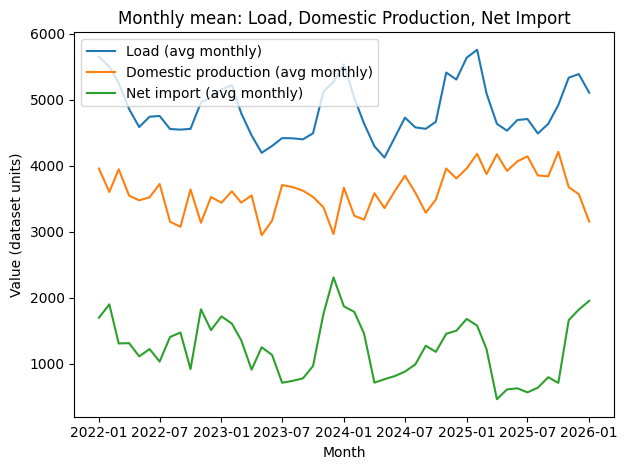


Annual net import share (sum-based):
          load_sum  net_import_sum  net_import_share_sum
year                                                    
2022  4.303619e+07    1.214946e+07              0.282308
2023  4.103139e+07    1.109887e+07              0.270497
2024  4.194288e+07    1.072913e+07              0.255803
2025  4.362909e+07    8.996992e+06              0.206215
2026  5.106158e+03    1.952474e+03              0.382376


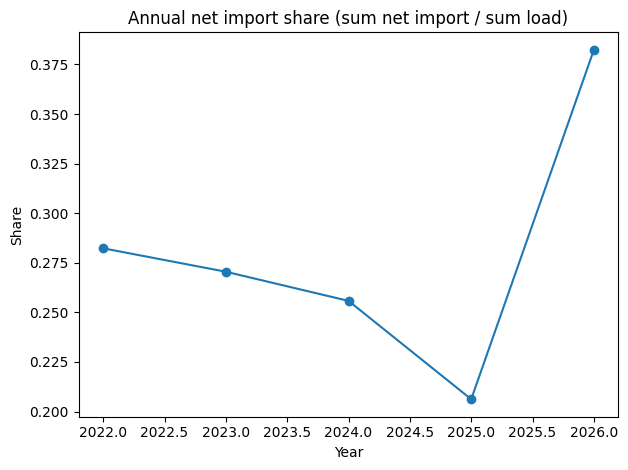

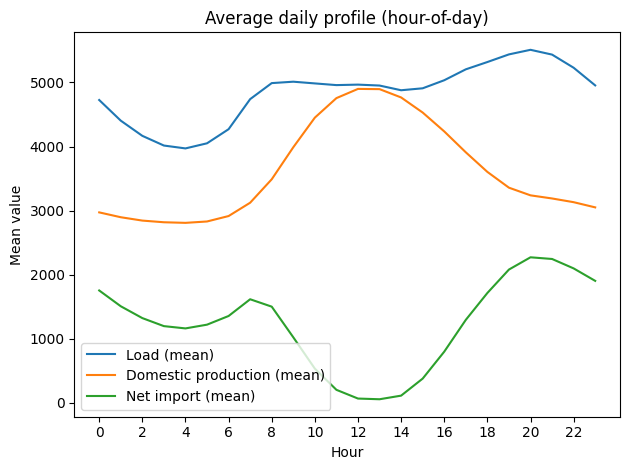

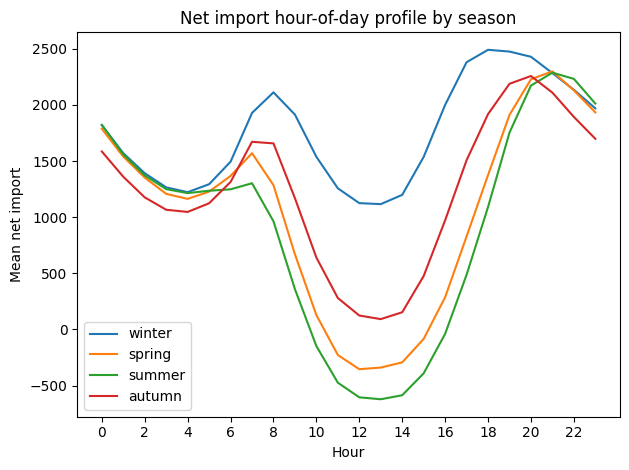

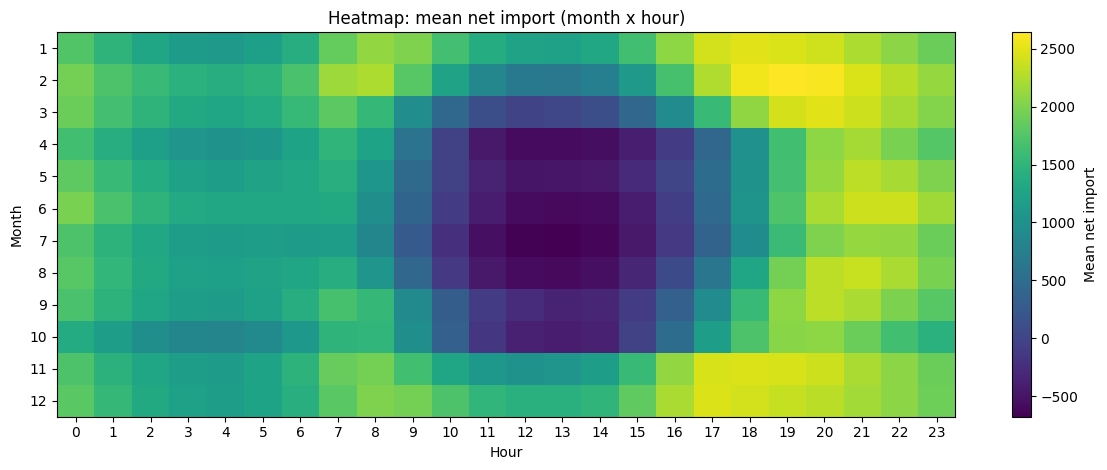

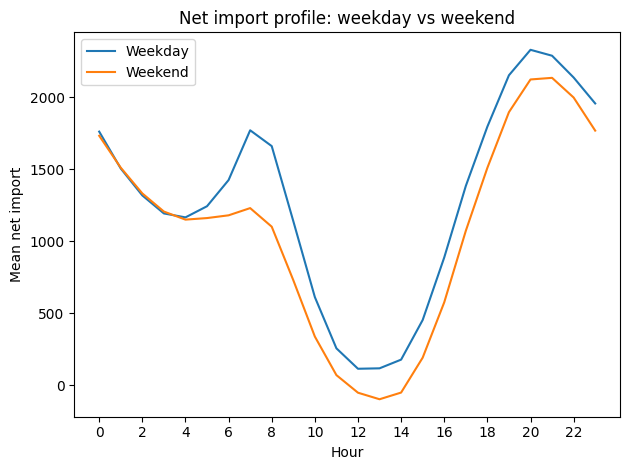


6) Distribution + top-import hours analysis
Net import p95: 2625.44
Net import p99: 3025.40


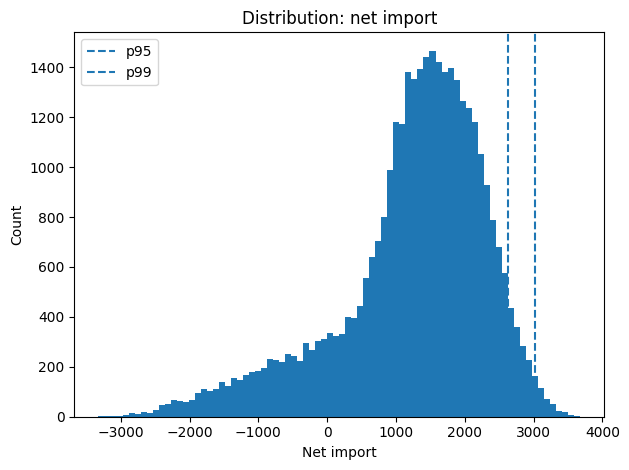


Top 1% hours summary:
                                                         mean         std  \
Nettó tény rendszerterhelés - net.ker.elsz.meres  6182.166459  439.421062   
Nettó hazai termelés tény                         3001.104026  454.188133   
net_import                                        3181.062336  129.725070   

                                                       min       max  
Nettó tény rendszerterhelés - net.ker.elsz.meres  5006.209  7086.140  
Nettó hazai termelés tény                         1951.178  3988.620  
net_import                                        3025.677  3673.956  

Rest hours summary:
                                                         mean          std  \
Nettó tény rendszerterhelés - net.ker.elsz.meres  4824.553088   768.529244   
Nettó hazai termelés tény                         3618.668892   996.665343   
net_import                                        1205.884133  1076.600311   

                                                  

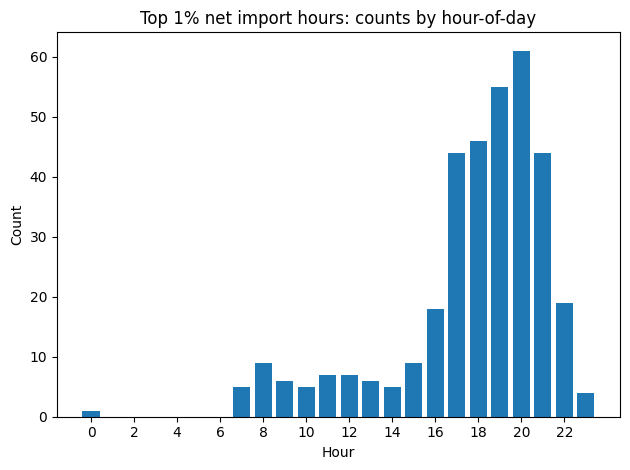

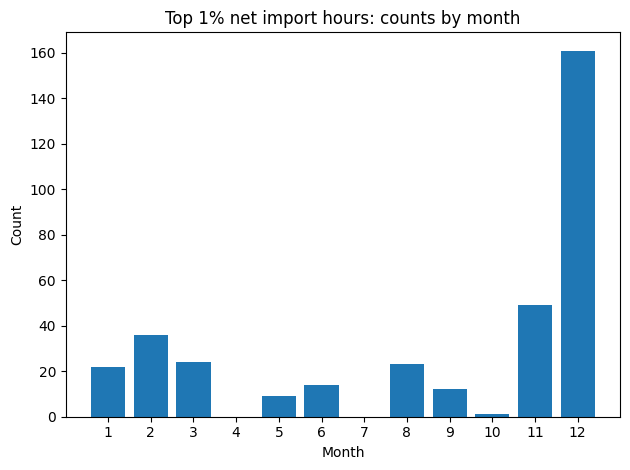


7) Plan vs actual diagnostics


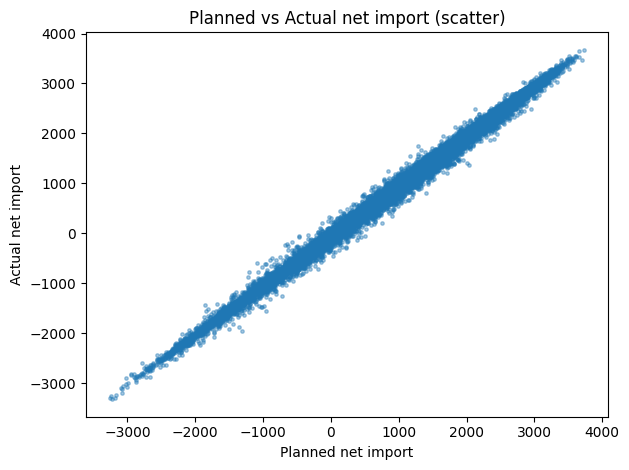

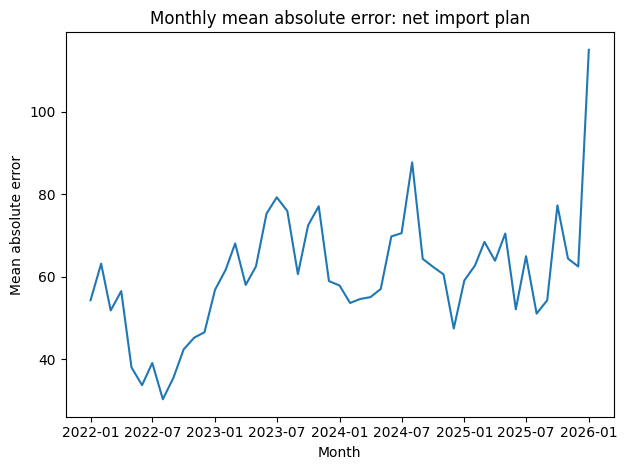

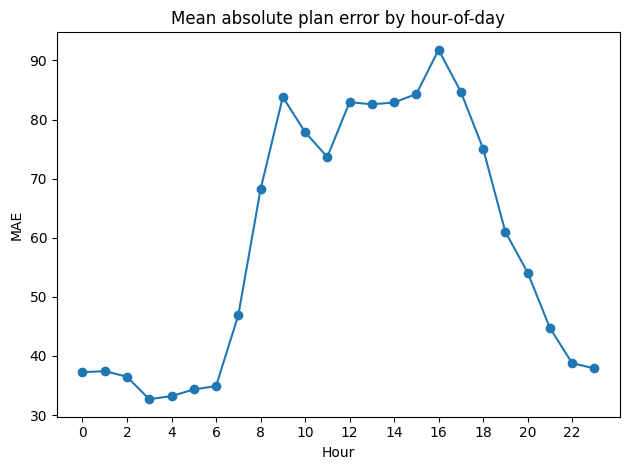


8) Rolling anomaly detection on net import
Anomalies (|z|>=4): 6


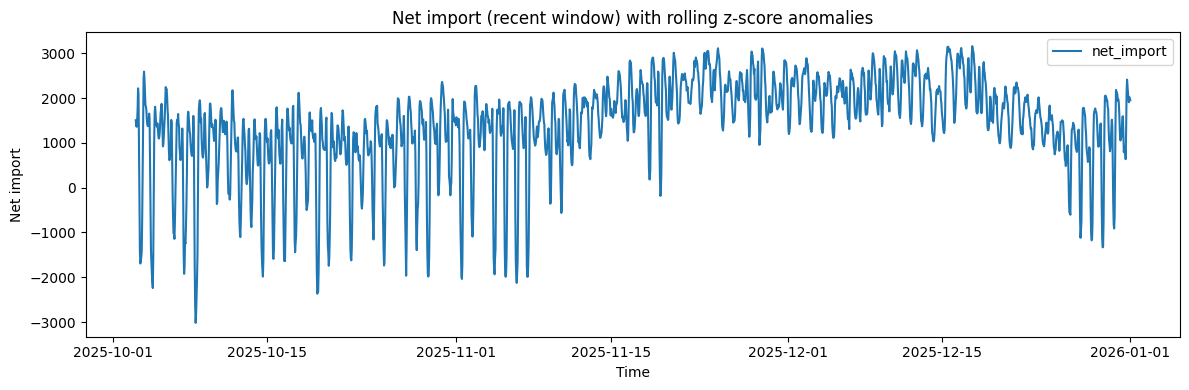


9) STL decomposition (daily net import)


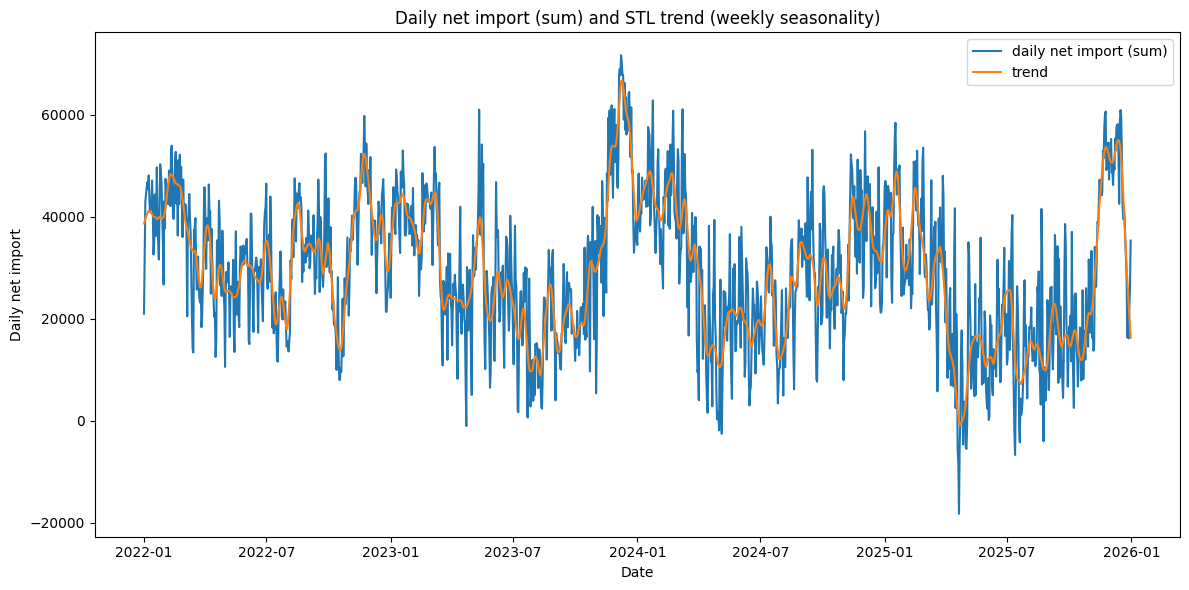

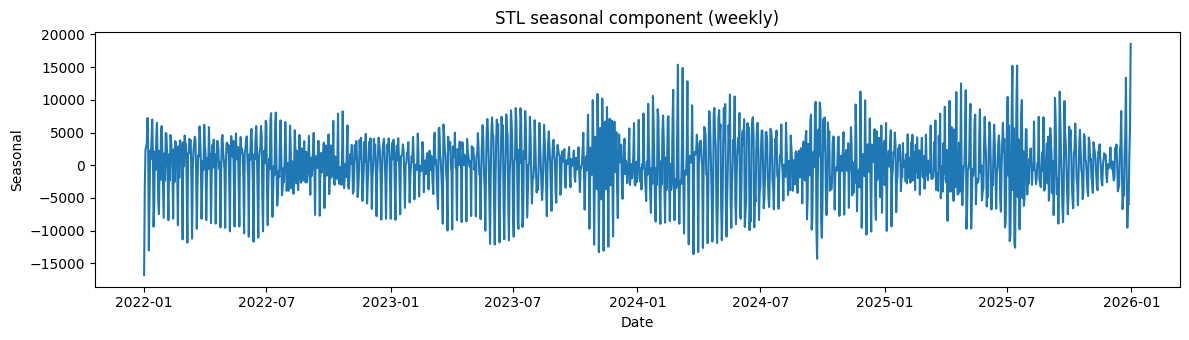

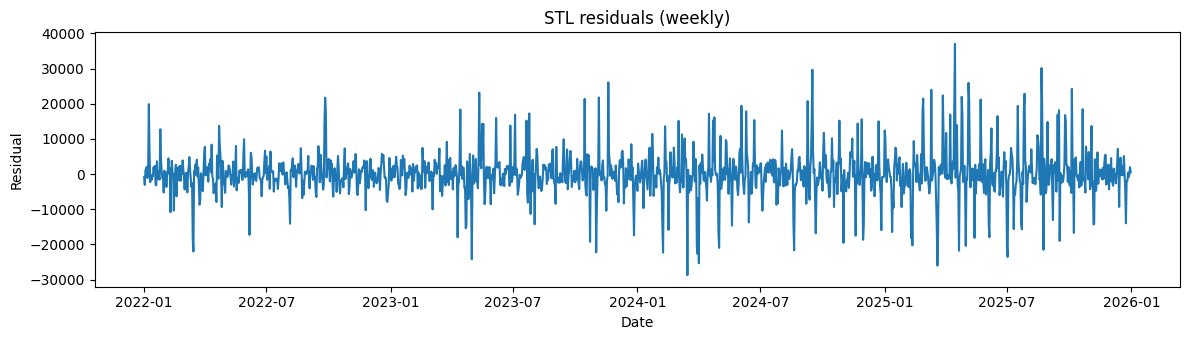


10) Simple driver model (Ridge, time-series CV)
CV MAE:  mean=0.000, std=0.000
CV RMSE: mean=0.000, std=0.000


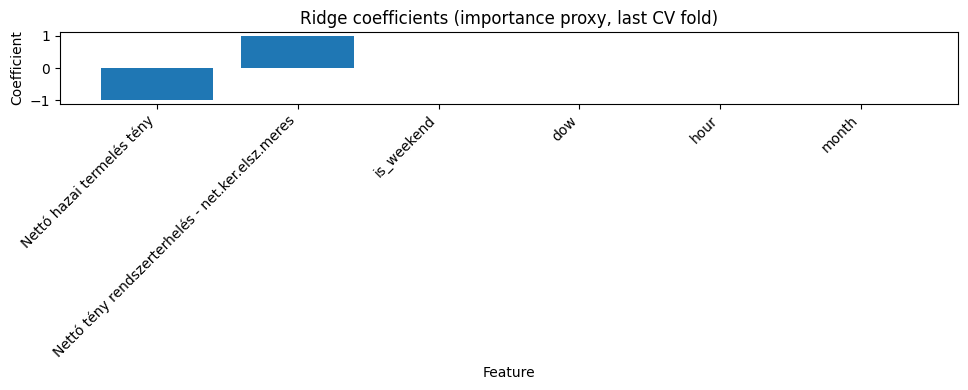


11) Import reduction scenario simulator
Peak shaving scenario (winter evenings, -2% load, proportional):
  Baseline net import (sum): 42,976,408.79
  Scenario net import (sum): 42,889,334.07
  Change (scenario-baseline): -87,074.72  (-0.203%)


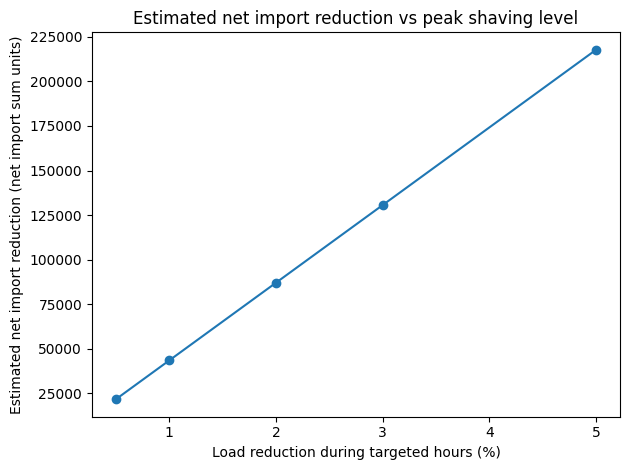


12) Summary tables (printed; CSV optional)
Hourly profile (head):
      Nettó tény rendszerterhelés - net.ker.elsz.meres  \
hour                                                     
0                                          4725.950550   
1                                          4403.794925   
2                                          4166.771075   
3                                          4015.330934   
4                                          3970.524626   

      Nettó hazai termelés tény   net_import  net_plan_import  \
hour                                                            
0                   2972.255961  1753.694486      1783.037138   
1                   2896.586465  1507.208395      1536.542353   
2                   2844.202391  1322.568621      1352.487929   
3                   2818.125569  1197.205336      1222.522237   
4                   2808.854956  1161.669643      1187.741880   

      abs_plan_error_net_import  
hour                             
0 

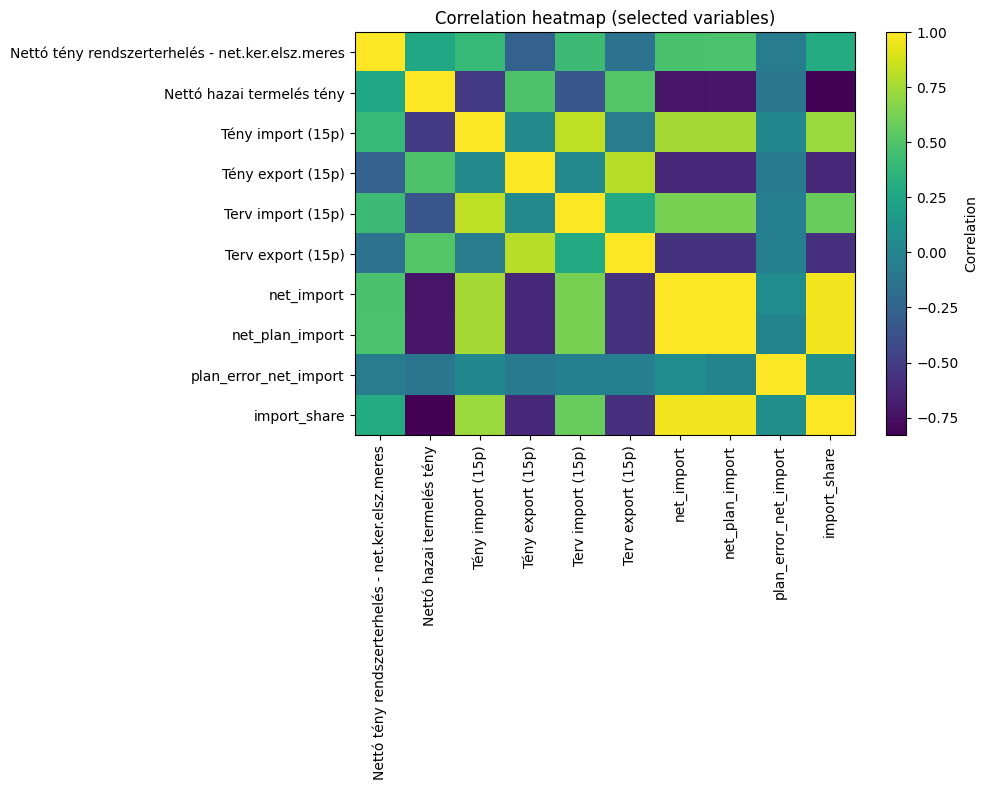

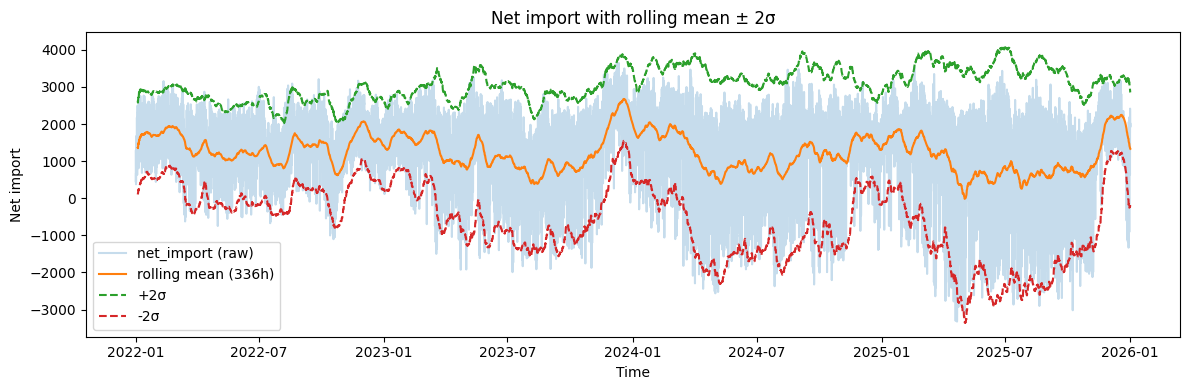

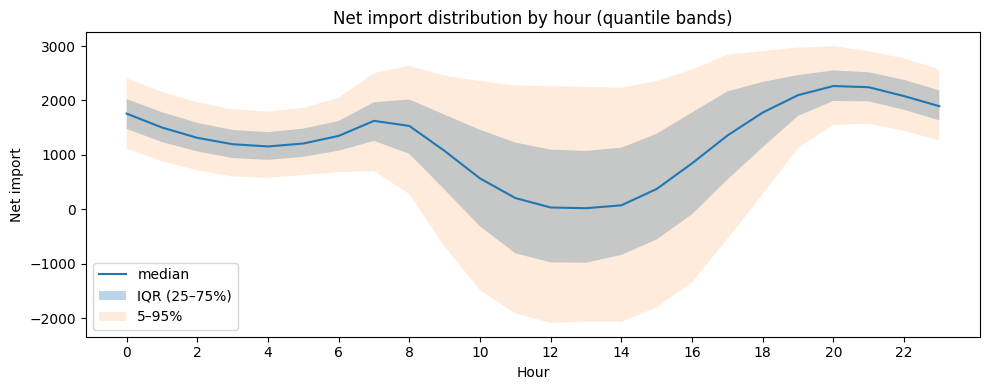

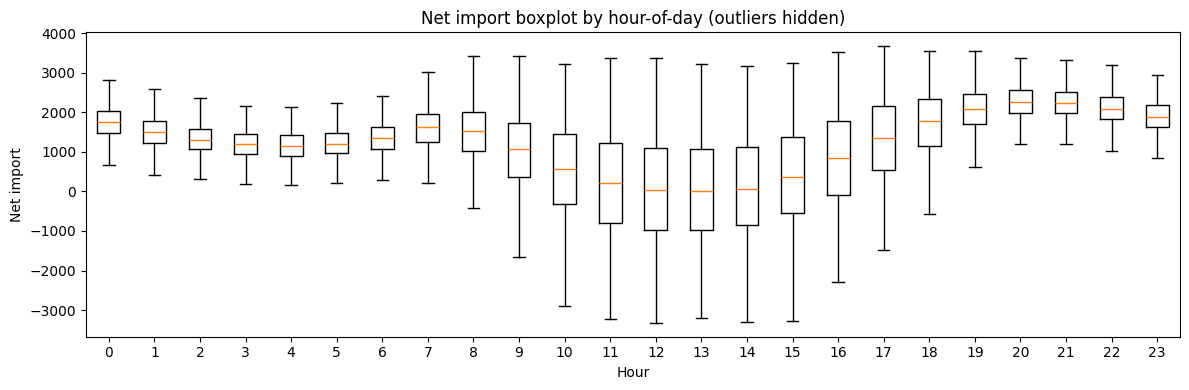

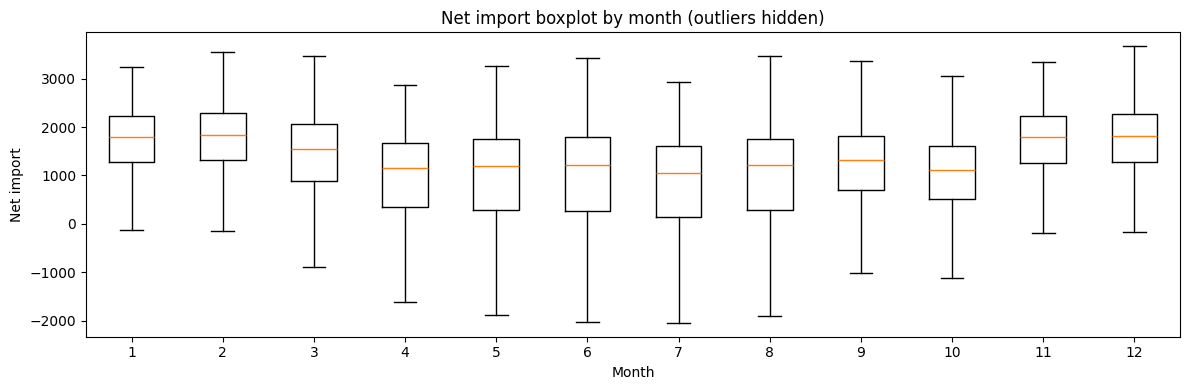

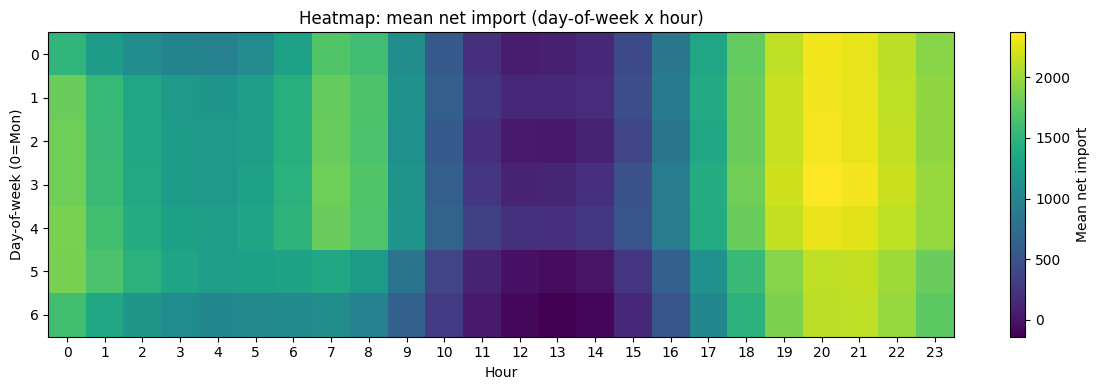

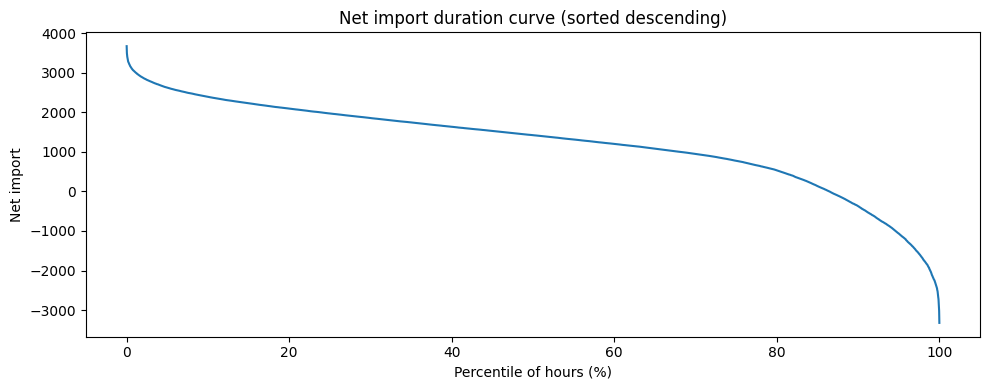

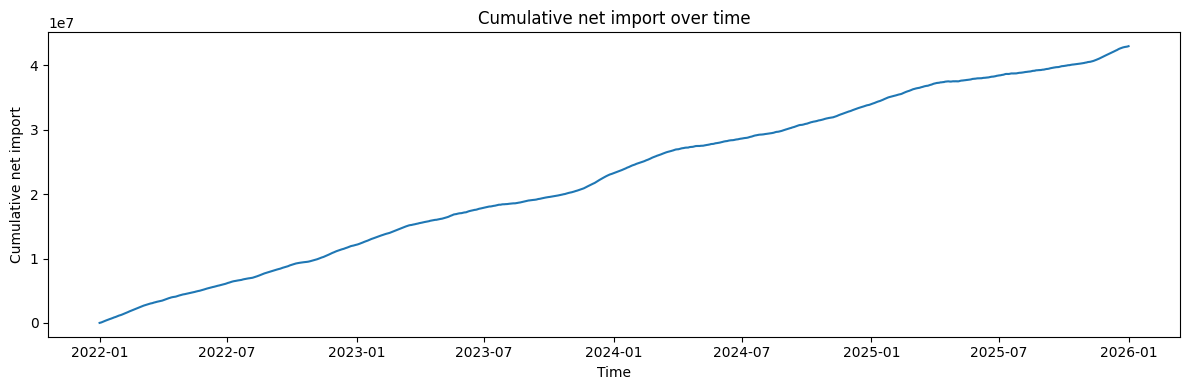

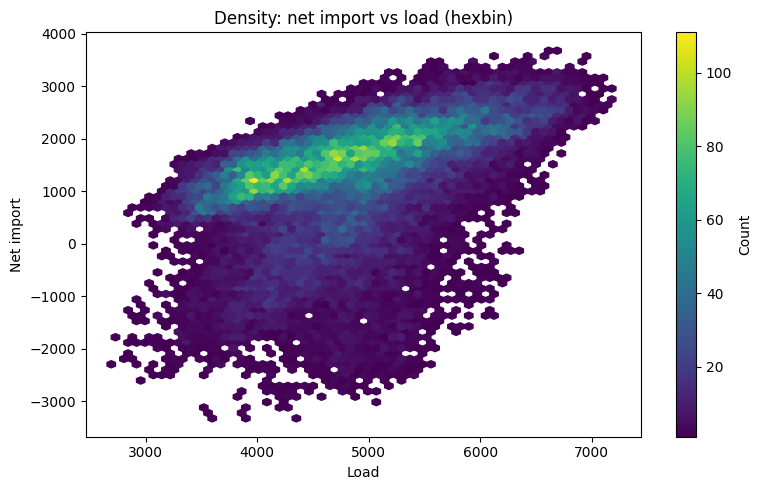

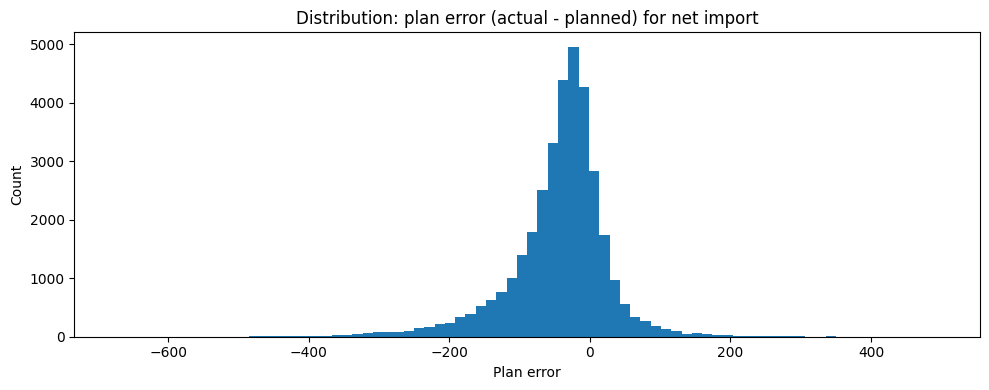

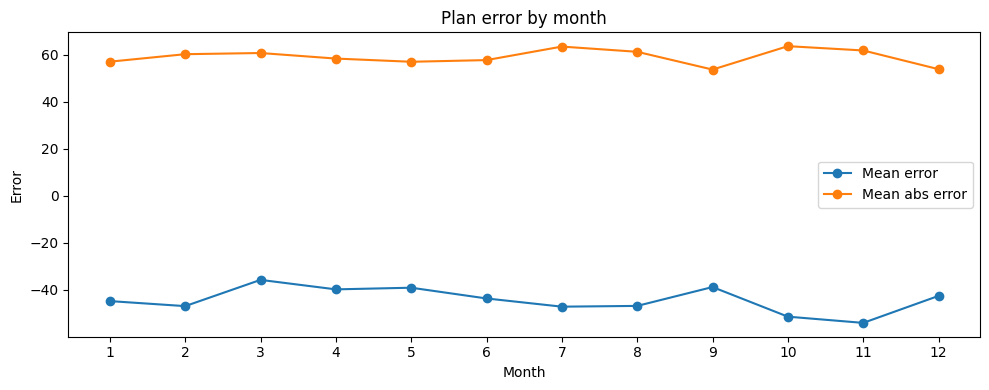

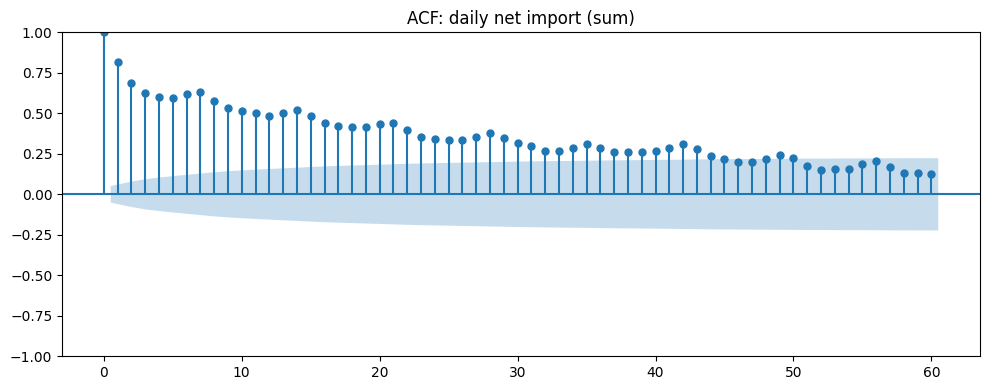

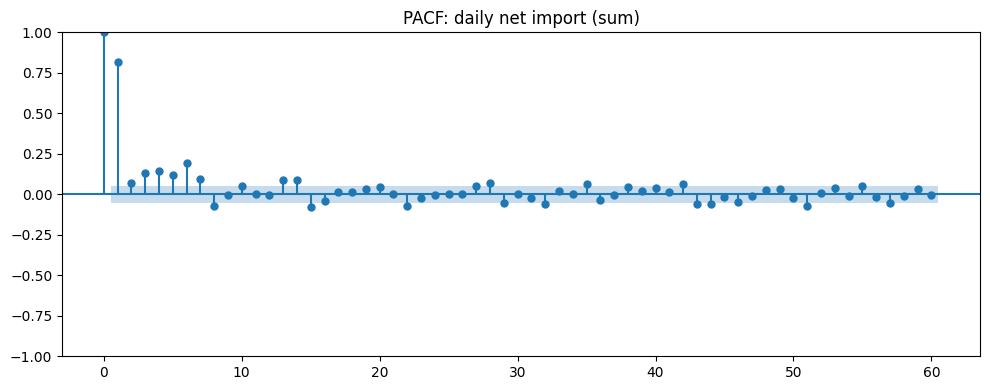

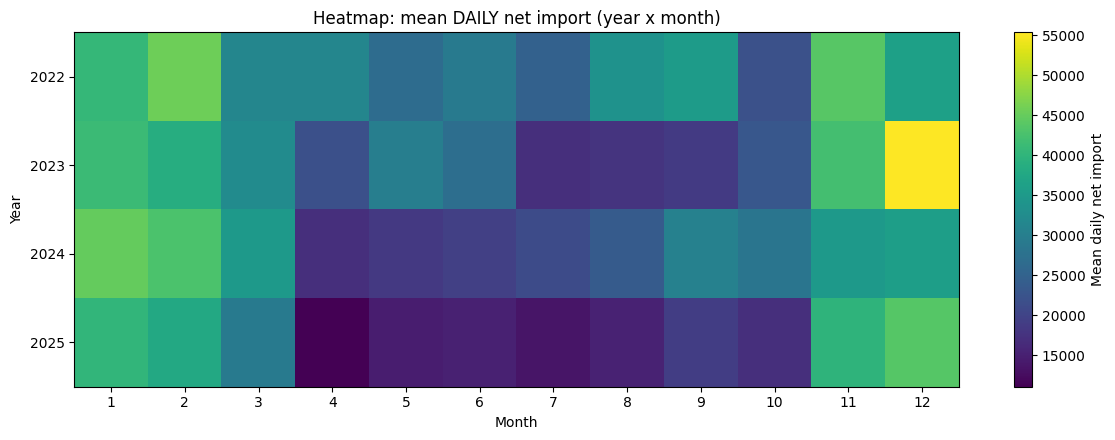


====
DONE
====
All plots were shown inline (no image export).


In [ ]:
# ------------------------------------------------------------
# Hungarian electricity dataset EDA + import-reduction analytics (Colab INLINE)
# File: "VER tényleges Nettó Forgalmi Óránkénti kumulált adatok.xlsx"
# Sheet: "Exportált adatok"
#
# This version:
# ✅ Shows ALL plots inline (no PNG export)
# ✅ Keeps the same analytics + adds a big visualization pack at the end
# ✅ Optional: can export CSV summaries if you flip CFG.export_csv=True
#
# Requirements:
#   pip install pandas numpy matplotlib openpyxl statsmodels scikit-learn
# NOTE: Uses matplotlib only (no seaborn).
# ------------------------------------------------------------

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------
# CONFIG
# -----------------------------
@dataclass
class Config:
    filepath: str = "VER tényleges Nettó Forgalmi Óránkénti kumulált adatok.xlsx"
    sheet_name: str = "Exportált adatok"
    tz: str = "Europe/Budapest"
    drop_all_nan_rows: bool = True

    # output toggles
    export_csv: bool = False      # set True if you want CSV files
    out_dir: str = "eda_outputs"  # used only if export_csv=True

CFG = Config()


# -----------------------------
# HELPERS
# -----------------------------
def print_block(title: str):
    print("\n" + "=" * len(title))
    print(title)
    print("=" * len(title))

def showfig():
    """Show current matplotlib figure inline, then close."""
    plt.tight_layout()
    plt.show()
    plt.close()

def safe_to_datetime_tz(series: pd.Series, tz: str) -> pd.Series:
    """
    Parse timestamps that may include timezone offsets.
    Strategy: parse as UTC (if possible), then convert to Europe/Budapest.
    Fallback: parse naive and localize with DST handling.
    """
    dt_utc = pd.to_datetime(series, utc=True, errors="coerce")
    if dt_utc.notna().mean() < 0.8:
        dt_naive = pd.to_datetime(series, errors="coerce")
        dt_local = dt_naive.dt.tz_localize(tz, ambiguous="infer", nonexistent="shift_forward")
        return dt_local
    return dt_utc.dt.tz_convert(tz)

def robust_quantile(x: pd.Series, q: float) -> float:
    x = pd.to_numeric(x, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    return float(x.quantile(q)) if len(x) else np.nan

def rolling_zscore(s: pd.Series, window: int = 24*14, min_periods: int = 24*7) -> pd.Series:
    s = s.astype(float)
    mu = s.rolling(window=window, min_periods=min_periods).mean()
    sd = s.rolling(window=window, min_periods=min_periods).std(ddof=0)
    return (s - mu) / sd


# -----------------------------
# LOAD + CLEAN
# -----------------------------
print_block("1) Load dataset")
df_raw = pd.read_excel(CFG.filepath, sheet_name=CFG.sheet_name)

print("Shape (raw):", df_raw.shape)
print("Columns:", list(df_raw.columns))

# Identify time column
time_col = None
for c in df_raw.columns:
    if str(c).strip().lower() in ["időpont", "idopont", "timestamp", "time", "date"]:
        time_col = c
        break
if time_col is None:
    raise ValueError("Could not find the timestamp column. Expected something like 'Időpont'.")

df = df_raw.copy()
df[time_col] = safe_to_datetime_tz(df[time_col], CFG.tz)

# Drop invalid time rows
df = df[df[time_col].notna()].copy()

# Convert other columns to numeric
for c in df.columns:
    if c == time_col:
        continue
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop all-NaN numeric placeholder rows
if CFG.drop_all_nan_rows:
    numeric_cols = [c for c in df.columns if c != time_col]
    mask_all_nan = df[numeric_cols].isna().all(axis=1)
    if mask_all_nan.any():
        print(f"Dropping {mask_all_nan.sum()} all-NaN numeric rows (placeholders).")
        df = df.loc[~mask_all_nan].copy()

# Sort, set index
df = df.sort_values(time_col).reset_index(drop=True).set_index(time_col)

print("Shape (clean):", df.shape)
print("Time range:", df.index.min(), "→", df.index.max())
print("Index tz:", df.index.tz)


# -----------------------------
# COLUMN MAPPING (best-effort)
# -----------------------------
print_block("2) Detect key columns")

def find_col_contains(substrings):
    subs = [s.lower() for s in (substrings if isinstance(substrings, (list, tuple)) else [substrings])]
    for c in df.columns:
        cl = str(c).lower()
        if all(s in cl for s in subs):
            return c
    return None

col_imp_act  = find_col_contains(["tény", "import"])
col_exp_act  = find_col_contains(["tény", "export"])
col_imp_plan = find_col_contains(["terv", "import"])
col_exp_plan = find_col_contains(["terv", "export"])

# Load / production columns
col_load_act = None
for candidate in [
    "Nettó tény rendszerterhelés - net.ker.elsz.meres",
    "Nettó tény rendszerterhelés",
    "Tény rendszerterhelés",
]:
    if candidate in df.columns:
        col_load_act = candidate
        break
if col_load_act is None:
    col_load_act = find_col_contains(["rendszerterhel"])

col_prod_act = None
for candidate in ["Nettó hazai termelés tény", "Hazai termelés tény", "Nettó hazai termelés"]:
    if candidate in df.columns:
        col_prod_act = candidate
        break
if col_prod_act is None:
    col_prod_act = find_col_contains(["hazai", "termel", "tény"])

col_small_act  = find_col_contains(["<50mw", "tény"])
col_small_plan = find_col_contains(["<50mw", "terv"])

print("Detected:")
print("  Actual import:", col_imp_act)
print("  Actual export:", col_exp_act)
print("  Planned import:", col_imp_plan)
print("  Planned export:", col_exp_plan)
print("  Actual load:", col_load_act)
print("  Actual domestic production:", col_prod_act)
print("  <50MW actual:", col_small_act)
print("  <50MW planned:", col_small_plan)

missing_critical = [name for name, col in [
    ("Actual import", col_imp_act),
    ("Actual export", col_exp_act),
    ("Planned import", col_imp_plan),
    ("Planned export", col_exp_plan),
    ("Actual load", col_load_act),
    ("Actual domestic production", col_prod_act),
] if col is None]
if missing_critical:
    raise ValueError(f"Missing critical columns: {missing_critical}. "
                     f"Please adjust find_col_contains rules or rename columns.")


# -----------------------------
# DERIVED FEATURES
# -----------------------------
print_block("3) Derived metrics + time features")

df["net_import"]      = df[col_imp_act] - df[col_exp_act]
df["net_plan_import"] = df[col_imp_plan] - df[col_exp_plan]

df["plan_error_net_import"]     = df["net_import"] - df["net_plan_import"]
df["abs_plan_error_net_import"] = df["plan_error_net_import"].abs()

df["import_share"] = np.where(df[col_load_act].abs() > 1e-9,
                              df["net_import"] / df[col_load_act],
                              np.nan)

df["year"]       = df.index.year
df["month"]      = df.index.month
df["day"]        = df.index.day
df["hour"]       = df.index.hour
df["dow"]        = df.index.dayofweek  # 0=Mon
df["is_weekend"] = (df["dow"] >= 5).astype(int)

def month_to_season(m):
    if m in [12, 1, 2]:  return "winter"
    if m in [3, 4, 5]:   return "spring"
    if m in [6, 7, 8]:   return "summer"
    return "autumn"

df["season"] = df["month"].map(month_to_season)

print(df[["net_import","net_plan_import","import_share","plan_error_net_import"]]
      .describe(percentiles=[.01,.05,.5,.95,.99]))


# -----------------------------
# DATA QUALITY CHECKS
# -----------------------------
print_block("4) Data quality checks")

dup_count = df.index.duplicated().sum()
print("Duplicate timestamps:", dup_count)

missing = df.isna().mean().sort_values(ascending=False)
print("\nTop missingness ratios:")
print(missing.head(10))

full_index = pd.date_range(df.index.min(), df.index.max(), freq="H", tz=CFG.tz)
missing_hours = full_index.difference(df.index)
print("\nExpected hours:", len(full_index))
print("Observed hours:", df.shape[0])
print("Missing hours (count):", len(missing_hours))
if len(missing_hours) > 0:
    print("First few missing hours:", list(missing_hours[:10]))


# -----------------------------
# 5) CORE EDA PLOTS (INLINE)
# -----------------------------
print_block("5) Core EDA plots")

monthly = df[[col_load_act, col_prod_act, "net_import", "net_plan_import"]].resample("MS").mean()

plt.figure()
plt.plot(monthly.index, monthly[col_load_act], label="Load (avg monthly)")
plt.plot(monthly.index, monthly[col_prod_act], label="Domestic production (avg monthly)")
plt.plot(monthly.index, monthly["net_import"], label="Net import (avg monthly)")
plt.title("Monthly mean: Load, Domestic Production, Net Import")
plt.xlabel("Month"); plt.ylabel("Value (dataset units)"); plt.legend()
showfig()

annual = df.groupby("year").agg(
    load_sum=(col_load_act, "sum"),
    net_import_sum=("net_import", "sum"),
)
annual["net_import_share_sum"] = np.where(annual["load_sum"].abs() > 1e-9,
                                         annual["net_import_sum"] / annual["load_sum"],
                                         np.nan)
print("\nAnnual net import share (sum-based):")
print(annual)

plt.figure()
plt.plot(annual.index, annual["net_import_share_sum"], marker="o")
plt.title("Annual net import share (sum net import / sum load)")
plt.xlabel("Year"); plt.ylabel("Share")
showfig()

hour_profile = df.groupby("hour")[[col_load_act, "net_import", col_prod_act]].mean()
plt.figure()
plt.plot(hour_profile.index, hour_profile[col_load_act], label="Load (mean)")
plt.plot(hour_profile.index, hour_profile[col_prod_act], label="Domestic production (mean)")
plt.plot(hour_profile.index, hour_profile["net_import"], label="Net import (mean)")
plt.title("Average daily profile (hour-of-day)")
plt.xlabel("Hour"); plt.ylabel("Mean value"); plt.xticks(range(0, 24, 2)); plt.legend()
showfig()

plt.figure()
for s in ["winter", "spring", "summer", "autumn"]:
    hp = df[df["season"] == s].groupby("hour")["net_import"].mean()
    plt.plot(hp.index, hp.values, label=s)
plt.title("Net import hour-of-day profile by season")
plt.xlabel("Hour"); plt.ylabel("Mean net import"); plt.xticks(range(0, 24, 2)); plt.legend()
showfig()

pivot = df.pivot_table(index="month", columns="hour", values="net_import", aggfunc="mean")
plt.figure(figsize=(12, 4.8))
plt.imshow(pivot.values, aspect="auto")
plt.title("Heatmap: mean net import (month x hour)")
plt.xlabel("Hour"); plt.ylabel("Month")
plt.xticks(np.arange(0, 24, 1), labels=[str(h) for h in range(24)])
plt.yticks(np.arange(0, len(pivot.index), 1), labels=[str(m) for m in pivot.index])
plt.colorbar(label="Mean net import")
showfig()

w_profile = df.groupby(["is_weekend", "hour"])["net_import"].mean().unstack(0)
plt.figure()
plt.plot(w_profile.index, w_profile[0], label="Weekday")
plt.plot(w_profile.index, w_profile[1], label="Weekend")
plt.title("Net import profile: weekday vs weekend")
plt.xlabel("Hour"); plt.ylabel("Mean net import"); plt.xticks(range(0, 24, 2)); plt.legend()
showfig()


# -----------------------------
# 6) DISTRIBUTIONS + EXTREMES
# -----------------------------
print_block("6) Distribution + top-import hours analysis")

p99 = robust_quantile(df["net_import"], 0.99)
p95 = robust_quantile(df["net_import"], 0.95)
print(f"Net import p95: {p95:.2f}")
print(f"Net import p99: {p99:.2f}")

plt.figure()
plt.hist(df["net_import"].dropna().values, bins=80)
plt.axvline(p95, linestyle="--", label="p95")
plt.axvline(p99, linestyle="--", label="p99")
plt.title("Distribution: net import")
plt.xlabel("Net import"); plt.ylabel("Count"); plt.legend()
showfig()

df["is_top1_netimport"] = (df["net_import"] >= p99).astype(int)

compare_cols = [col_load_act, col_prod_act, "net_import"]
if col_small_act is not None:
    compare_cols.append(col_small_act)

summary_top  = df[df["is_top1_netimport"] == 1][compare_cols].describe().T[["mean","std","min","max"]]
summary_rest = df[df["is_top1_netimport"] == 0][compare_cols].describe().T[["mean","std","min","max"]]
print("\nTop 1% hours summary:")
print(summary_top)
print("\nRest hours summary:")
print(summary_rest)

top_hour_counts = df[df["is_top1_netimport"] == 1]["hour"].value_counts().sort_index()
plt.figure()
plt.bar(top_hour_counts.index, top_hour_counts.values)
plt.title("Top 1% net import hours: counts by hour-of-day")
plt.xlabel("Hour"); plt.ylabel("Count"); plt.xticks(range(0, 24, 2))
showfig()

top_month_counts = df[df["is_top1_netimport"] == 1]["month"].value_counts().sort_index()
plt.figure()
plt.bar(top_month_counts.index, top_month_counts.values)
plt.title("Top 1% net import hours: counts by month")
plt.xlabel("Month"); plt.ylabel("Count"); plt.xticks(range(1, 13))
showfig()


# -----------------------------
# 7) PLAN VS ACTUAL DIAGNOSTICS
# -----------------------------
print_block("7) Plan vs actual diagnostics")

plt.figure()
plt.scatter(df["net_plan_import"], df["net_import"], s=6, alpha=0.4)
lims = [
    np.nanpercentile(np.r_[df["net_plan_import"].values, df["net_import"].values], 1),
    np.nanpercentile(np.r_[df["net_plan_import"].values, df["net_import"].values], 99),
]
plt.plot(lims, lims, linestyle="--")
plt.title("Planned vs Actual net import (scatter)")
plt.xlabel("Planned net import"); plt.ylabel("Actual net import")
showfig()

mae_month = df["abs_plan_error_net_import"].resample("MS").mean()
plt.figure()
plt.plot(mae_month.index, mae_month.values)
plt.title("Monthly mean absolute error: net import plan")
plt.xlabel("Month"); plt.ylabel("Mean absolute error")
showfig()

err_hour = df.groupby("hour")["abs_plan_error_net_import"].mean()
plt.figure()
plt.plot(err_hour.index, err_hour.values, marker="o")
plt.title("Mean absolute plan error by hour-of-day")
plt.xlabel("Hour"); plt.ylabel("MAE"); plt.xticks(range(0, 24, 2))
showfig()


# -----------------------------
# 8) ANOMALY DETECTION (rolling z-score)
# -----------------------------
print_block("8) Rolling anomaly detection on net import")

df["net_import_z"] = rolling_zscore(df["net_import"], window=24*14, min_periods=24*7)
anoms = df[df["net_import_z"].abs() >= 4].copy()
print("Anomalies (|z|>=4):", len(anoms))

recent = df.last("90D").copy() if len(df) > 24*90 else df.copy()
plt.figure(figsize=(12, 4))
plt.plot(recent.index, recent["net_import"], label="net_import")
anoms_recent = anoms.loc[anoms.index.intersection(recent.index)]
if len(anoms_recent) > 0:
    plt.scatter(anoms_recent.index, anoms_recent["net_import"], s=20, label="|z|>=4 anomalies")
plt.title("Net import (recent window) with rolling z-score anomalies")
plt.xlabel("Time"); plt.ylabel("Net import"); plt.legend()
showfig()


# -----------------------------
# 9) STL decomposition (DAILY net import)
# -----------------------------
print_block("9) STL decomposition (daily net import)")

daily = df["net_import"].resample("D").sum(min_count=12).dropna()
stl = STL(daily, period=7, robust=True).fit()

plt.figure(figsize=(12, 6))
plt.plot(daily.index, daily.values, label="daily net import (sum)")
plt.plot(daily.index, stl.trend.values, label="trend")
plt.title("Daily net import (sum) and STL trend (weekly seasonality)")
plt.xlabel("Date"); plt.ylabel("Daily net import"); plt.legend()
showfig()

plt.figure(figsize=(12, 3.5))
plt.plot(daily.index, stl.seasonal.values)
plt.title("STL seasonal component (weekly)")
plt.xlabel("Date"); plt.ylabel("Seasonal")
showfig()

plt.figure(figsize=(12, 3.5))
plt.plot(daily.index, stl.resid.values)
plt.title("STL residuals (weekly)")
plt.xlabel("Date"); plt.ylabel("Residual")
showfig()


# -----------------------------
# 10) SIMPLE DRIVER MODEL (Ridge regression, time series CV)
# -----------------------------
print_block("10) Simple driver model (Ridge, time-series CV)")

features = [col_load_act, col_prod_act, "hour", "dow", "month", "is_weekend"]
if col_small_act is not None:
    features.append(col_small_act)

model_df = df[features + ["net_import"]].dropna().copy()
X = model_df[features].astype(float).values
y = model_df["net_import"].astype(float).values

tscv = TimeSeriesSplit(n_splits=5)
maes, rmses = [], []
last_coef = None

ridge = Ridge(alpha=1.0)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    ridge.fit(X_train, y_train)
    pred = ridge.predict(X_test)

    maes.append(mean_absolute_error(y_test, pred))
    rmses.append(np.sqrt(mean_squared_error(y_test, pred)))

    if fold == tscv.get_n_splits():
        last_coef = ridge.coef_.copy()

print(f"CV MAE:  mean={np.mean(maes):.3f}, std={np.std(maes):.3f}")
print(f"CV RMSE: mean={np.mean(rmses):.3f}, std={np.std(rmses):.3f}")

if last_coef is not None:
    order = np.argsort(np.abs(last_coef))[::-1]
    plt.figure(figsize=(10, 4))
    plt.bar([features[i] for i in order], last_coef[order])
    plt.title("Ridge coefficients (importance proxy, last CV fold)")
    plt.xlabel("Feature"); plt.ylabel("Coefficient")
    plt.xticks(rotation=45, ha="right")
    showfig()


# -----------------------------
# 11) SCENARIO SIMULATOR (Peak shaving)
# -----------------------------
print_block("11) Import reduction scenario simulator")

def simulate_peak_shaving(
    data: pd.DataFrame,
    load_col: str,
    net_import_col: str = "net_import",
    hours=(17, 18, 19, 20, 21),
    months=(12, 1, 2),
    load_reduction_pct=0.02,
    proportional=True
):
    d = data.copy()
    mask = d["hour"].isin(hours) & d["month"].isin(months)
    baseline = d[net_import_col].sum()

    if proportional:
        d.loc[mask, net_import_col] = d.loc[mask, net_import_col] * (1 - load_reduction_pct)
    else:
        d.loc[mask, net_import_col] = d.loc[mask, net_import_col] - d.loc[mask, load_col] * load_reduction_pct

    scenario = d[net_import_col].sum()
    delta = scenario - baseline
    pct = delta / baseline if baseline != 0 else np.nan
    return baseline, scenario, delta, pct

baseline, scenario, delta, pct = simulate_peak_shaving(
    df.dropna(subset=[col_load_act, "net_import"]),
    load_col=col_load_act,
    load_reduction_pct=0.02
)

print("Peak shaving scenario (winter evenings, -2% load, proportional):")
print(f"  Baseline net import (sum): {baseline:,.2f}")
print(f"  Scenario net import (sum): {scenario:,.2f}")
print(f"  Change (scenario-baseline): {delta:,.2f}  ({pct*100:.3f}%)")

levels = [0.005, 0.01, 0.02, 0.03, 0.05]
impacts = []
for lv in levels:
    b, s, dlt, p = simulate_peak_shaving(
        df.dropna(subset=[col_load_act, "net_import"]),
        load_col=col_load_act,
        load_reduction_pct=lv
    )
    impacts.append(-dlt)

plt.figure()
plt.plot([lv*100 for lv in levels], impacts, marker="o")
plt.title("Estimated net import reduction vs peak shaving level")
plt.xlabel("Load reduction during targeted hours (%)")
plt.ylabel("Estimated net import reduction (net import sum units)")
showfig()


# -----------------------------
# 12) OPTIONAL: EXPORT SUMMARY TABLES (CSV)
# -----------------------------
print_block("12) Summary tables (printed; CSV optional)")

hour_profile_out = df.groupby("hour")[[col_load_act, col_prod_act, "net_import", "net_plan_import",
                                      "abs_plan_error_net_import"]].mean()

print("Hourly profile (head):")
print(hour_profile_out.head())

top_hours = df.sort_values("net_import", ascending=False).head(20).copy()
top_hours_out_cols = [col_load_act, col_prod_act, "net_import", "net_plan_import", "plan_error_net_import",
                      "hour", "dow", "month", "season", "is_weekend"]
for extra in [col_small_act, col_small_plan]:
    if extra is not None and extra in df.columns:
        top_hours_out_cols.append(extra)

print("\nTop 20 net import hours (head):")
print(top_hours[top_hours_out_cols].head())

print("\nAnnual summary:")
print(annual)

if CFG.export_csv:
    import os
    os.makedirs(CFG.out_dir, exist_ok=True)
    hour_profile_out.to_csv(f"{CFG.out_dir}/hour_profile_summary.csv")
    top_hours[top_hours_out_cols].to_csv(f"{CFG.out_dir}/top20_net_import_hours.csv")
    annual.to_csv(f"{CFG.out_dir}/annual_net_import_share.csv")
    print(f"\nCSV exported to folder: {CFG.out_dir}")


# ------------------------------------------------------------
# 13) EXTRA VISUALIZATION PACK (more diagrams, all INLINE)
# ------------------------------------------------------------
print_block("13) Extra visualization pack (more diagrams)")

# A) Correlation heatmap (selected vars)
corr_cols = [
    col_load_act, col_prod_act,
    col_imp_act, col_exp_act,
    col_imp_plan, col_exp_plan,
    "net_import", "net_plan_import",
    "plan_error_net_import", "import_share"
]
for c in [col_small_act, col_small_plan]:
    if c is not None and c in df.columns:
        corr_cols.append(c)

corr_df = df[corr_cols].copy()
corr = corr_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr.values, aspect="auto")
plt.title("Correlation heatmap (selected variables)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(label="Correlation")
showfig()

# B) Rolling mean + std bands
roll_w = 24 * 14
net = df["net_import"].astype(float)
roll_mean = net.rolling(roll_w, min_periods=24*3).mean()
roll_std  = net.rolling(roll_w, min_periods=24*3).std()

plt.figure(figsize=(12, 4))
plt.plot(net.index, net.values, alpha=0.25, label="net_import (raw)")
plt.plot(roll_mean.index, roll_mean.values, label=f"rolling mean ({roll_w}h)")
plt.plot(roll_mean.index, (roll_mean + 2*roll_std).values, linestyle="--", label="+2σ")
plt.plot(roll_mean.index, (roll_mean - 2*roll_std).values, linestyle="--", label="-2σ")
plt.title("Net import with rolling mean ± 2σ")
plt.xlabel("Time"); plt.ylabel("Net import"); plt.legend()
showfig()

# C) Hourly quantile bands ("fan chart")
q = df.groupby("hour")["net_import"].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).unstack()

plt.figure(figsize=(10, 4))
plt.plot(q.index, q[0.5], label="median")
plt.fill_between(q.index, q[0.25], q[0.75], alpha=0.3, label="IQR (25–75%)")
plt.fill_between(q.index, q[0.05], q[0.95], alpha=0.15, label="5–95%")
plt.title("Net import distribution by hour (quantile bands)")
plt.xlabel("Hour"); plt.ylabel("Net import"); plt.xticks(range(0, 24, 2)); plt.legend()
showfig()

# D) Boxplots by hour-of-day (outliers hidden)
data_by_hour = [df[df["hour"] == h]["net_import"].dropna().values for h in range(24)]
plt.figure(figsize=(12, 4))
plt.boxplot(data_by_hour, showfliers=False)
plt.title("Net import boxplot by hour-of-day (outliers hidden)")
plt.xlabel("Hour"); plt.ylabel("Net import")
plt.xticks(range(1, 25), [str(h) for h in range(24)])
showfig()

# E) Boxplots by month (outliers hidden)
data_by_month = [df[df["month"] == m]["net_import"].dropna().values for m in range(1, 13)]
plt.figure(figsize=(12, 4))
plt.boxplot(data_by_month, showfliers=False)
plt.title("Net import boxplot by month (outliers hidden)")
plt.xlabel("Month"); plt.ylabel("Net import")
plt.xticks(range(1, 13), [str(m) for m in range(1, 13)])
showfig()

# F) Day-of-week x hour heatmap
dow_hour = df.pivot_table(index="dow", columns="hour", values="net_import", aggfunc="mean")
plt.figure(figsize=(12, 4))
plt.imshow(dow_hour.values, aspect="auto")
plt.title("Heatmap: mean net import (day-of-week x hour)")
plt.xlabel("Hour"); plt.ylabel("Day-of-week (0=Mon)")
plt.xticks(np.arange(0, 24, 1), labels=[str(h) for h in range(24)])
plt.yticks(np.arange(0, 7, 1), labels=[str(d) for d in dow_hour.index])
plt.colorbar(label="Mean net import")
showfig()

# G) Duration curve
sorted_net = np.sort(df["net_import"].dropna().values)[::-1]
x = np.linspace(0, 100, len(sorted_net))
plt.figure(figsize=(10, 4))
plt.plot(x, sorted_net)
plt.title("Net import duration curve (sorted descending)")
plt.xlabel("Percentile of hours (%)")
plt.ylabel("Net import")
showfig()

# H) Cumulative net import
cum_net = df["net_import"].cumsum()
plt.figure(figsize=(12, 4))
plt.plot(cum_net.index, cum_net.values)
plt.title("Cumulative net import over time")
plt.xlabel("Time"); plt.ylabel("Cumulative net import")
showfig()

# I) Density: net import vs load (hexbin)
xv = df[col_load_act]
yv = df["net_import"]
mask = xv.notna() & yv.notna()
plt.figure(figsize=(8, 5))
plt.hexbin(xv[mask].values, yv[mask].values, gridsize=60, mincnt=1)
plt.title("Density: net import vs load (hexbin)")
plt.xlabel("Load"); plt.ylabel("Net import")
plt.colorbar(label="Count")
showfig()

# J) Plan error distribution + by month
err = df["plan_error_net_import"].dropna()
plt.figure(figsize=(10, 4))
plt.hist(err.values, bins=80)
plt.title("Distribution: plan error (actual - planned) for net import")
plt.xlabel("Plan error"); plt.ylabel("Count")
showfig()

err_month = df.groupby("month")["plan_error_net_import"].mean()
err_month_mae = df.groupby("month")["abs_plan_error_net_import"].mean()

plt.figure(figsize=(10, 4))
plt.plot(err_month.index, err_month.values, marker="o", label="Mean error")
plt.plot(err_month_mae.index, err_month_mae.values, marker="o", label="Mean abs error")
plt.title("Plan error by month")
plt.xlabel("Month"); plt.ylabel("Error"); plt.xticks(range(1, 13)); plt.legend()
showfig()

# K) ACF / PACF of DAILY net import
daily2 = df["net_import"].resample("D").sum(min_count=12).dropna()

plt.figure(figsize=(10, 4))
plot_acf(daily2.values, lags=60, ax=plt.gca())
plt.title("ACF: daily net import (sum)")
showfig()

plt.figure(figsize=(10, 4))
plot_pacf(daily2.values, lags=60, ax=plt.gca(), method="ywm")
plt.title("PACF: daily net import (sum)")
showfig()

# L) Year x month heatmap (mean daily net import)
daily_df = daily2.to_frame("daily_net_import")
daily_df["year"] = daily_df.index.year
daily_df["month"] = daily_df.index.month
ym = daily_df.pivot_table(index="year", columns="month", values="daily_net_import", aggfunc="mean")

plt.figure(figsize=(12, 4.5))
plt.imshow(ym.values, aspect="auto")
plt.title("Heatmap: mean DAILY net import (year x month)")
plt.xlabel("Month"); plt.ylabel("Year")
plt.xticks(np.arange(0, 12, 1), labels=[str(m) for m in range(1, 13)])
plt.yticks(np.arange(0, len(ym.index), 1), labels=[str(y) for y in ym.index])
plt.colorbar(label="Mean daily net import")
showfig()

print_block("DONE")
print("All plots were shown inline (no image export).")